In [1]:
!pip install --upgrade pandas-profiling
!pip install shap

  Using cached joblib-1.1.1-py2.py3-none-any.whl.metadata (5.2 kB)
Using cached joblib-1.1.1-py2.py3-none-any.whl (309 kB)
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.1
    Uninstalling joblib-1.5.1:
      Successfully uninstalled joblib-1.5.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
econml 0.15.1 requires scikit-learn<1.6,>=1.0, but you have scikit-learn 1.6.1 which is incompatible.
responsibleai 0.36.0 requires pandas<2.0.0,>=0.25.1, but you have pandas 2.2.3 which is incompatible.
responsibleai 0.36.0 requires scikit-learn!=1.1,<=1.5.1,>=0.22.1, but you have scikit-learn 1.6.1 which is incompatible.
scikit-learn 1.6.1 requires joblib>=1.2.0, but you have joblib 1.1.1 which is incompatible.
ydata-profiling 4.14.0 requires visions[type_image_path]<0.8.2,>=0.7.5, but you have visions 0.7.4 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\TaeyoonKim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
Using cached joblib-1.5.1-py3-none-any.whl (307 kB)
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.1
    Uninstalling joblib-1.1.1:
      Successfully uninstalled joblib-1.1.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
econml 0.15.1 requires scikit-learn<1.6,>=1.0, but you have scikit-learn 1.6.1 which is incompatible.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.5.1 which is incompatible.
responsibleai 0.36.0 requires pandas<2.0.0,>=0.25.1, but you have pandas 2.2.3 which is incompatible.
responsibleai 0.36.0 requires scikit-learn!=1.1,<=1.5.1,>=0.22.1, but you have scikit-learn 1.6.1 which is incompatible.
ydata-profiling 4.14.0 requires visions[type_image_path]<0.8.2,>=0.7.5, but you have visions 0.7.4 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\TaeyoonKim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
# library for feature engineering and EDA
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from IPython.display import Image
import pandas_profiling
from datetime import datetime
import random

# library for statistic
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import uniform as sp_randFloat
from scipy.stats import randint as sp_randInt


# library for sampling 
from imblearn.over_sampling import SMOTE

# library for machine learning
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

import shap
%matplotlib inline

C:\Users\TaeyoonKim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numba\core\decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)
C:\Users\TaeyoonKim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\visions\backends\shared\nan_handling.py:50: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-

C:\Users\TaeyoonKim\AppData\Local\Temp\ipykernel_38024\2582352975.py:9: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  import pandas_profiling


In [2]:
data_path = ""
random_state = 42

In [3]:
df = pd.read_csv(data_path + "data/data.csv")
df.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


In [4]:
print("Duplicated:", len(df[df.duplicated()])) 

Duplicated: 0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

In [6]:
for column_name in list(df.columns):
    print(column_name, df[column_name].dtype, df[column_name].unique())

CustomerID int64 [3000002 3000010 3000014 ... 3399978 3399990 3399994]
Churn object ['Yes' 'No']
MonthlyRevenue float64 [ 24.    16.99  38.   ...  27.11 534.93 109.96]
MonthlyMinutes float64 [ 219.   10.    8. ... 3360. 4719. 2437.]
TotalRecurringCharge float64 [ 22.  17.  38.  75.  52.  30.  66.  35.  25.  85.  37.  60.  70. 100.
  50.  55.  68.  20.  45. 150.  83.  19.  71.  15.  58.  89.  95.  78.
  80.  77. 183. 213.  87.  27. 108.  32.  59.   5.  40.  10. 105. 107.
  74.  nan 102. 140.  63.  93. 202.  49.  48.  81.  57.  24.  21.  47.
  97. 160. 110.  82.  42.  36. 115.  76.   7. 200. 207.  31.  92. 101.
  91.  90.  62. 300.  56. 121.  99.   8.   9.  79.  67.  73.  84.  65.
  43.  61. 120.  18.  53.  12.  64.  11.  41.  44.  86.  88. 210. 106.
  54.  13.  29.  34.   0. 155.  98. 281. 112.  28.  46. 175.  51. 117.
 138.  16. 180. 170.  39. 103.  72. 338.  26.  96. 151. 119. 135.  33.
 169.  23. 219.   4. 232.  94.  69. 149. 127. 146. 174. 130. 172. 182.
 116. 126.  14. 104. 157.  -

In [7]:
list_casting_as_object = ["CustomerID", "IncomeGroup", "ReferralsMadeBySubscriber", "HandsetModels"]
for column_name in list_casting_as_object:
    df[column_name] = df[column_name].astype("object")

<Axes: xlabel='count', ylabel='HandsetPrice'>

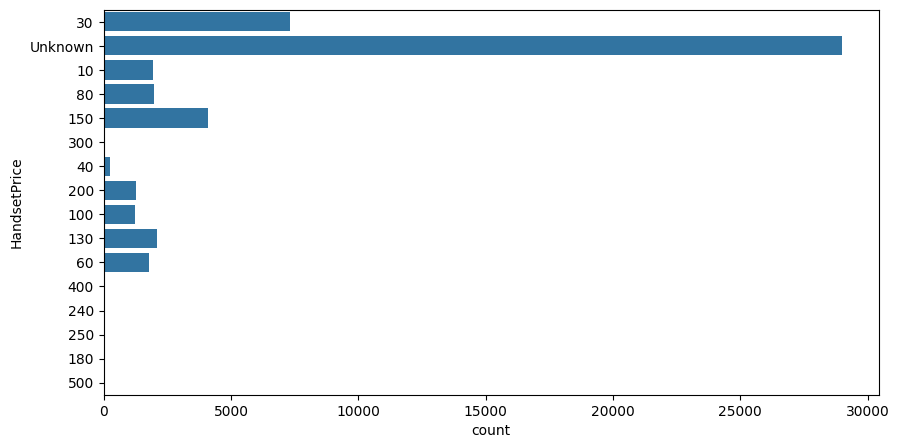

In [8]:
# HandsetPrice에 NaN 포함되어 있는 것을 확인
plt.figure(figsize=(10,5))
sns.countplot(df["HandsetPrice"])

In [9]:
# HandsetPrice 50프로 이상의 값이 NaN이므로 제거하기로 결정
df = df.drop("HandsetPrice", axis=1)

In [10]:
df

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,No,0,4,No,0,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,No,0,5,No,0,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,No,0,6,No,0,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,No,0,6,No,0,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,Yes,0,9,No,1,No,1-Highest,Other,Professional,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51042,3399958,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,No,0,6,No,0,No,1-Highest,Suburban,Other,Yes
51043,3399974,No,95.17,1745.0,85.0,0.99,45.0,4.7,122.0,15.9,...,No,0,9,No,1,No,3-Good,Other,Other,No
51044,3399978,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,No,0,7,No,1,No,5-Low,Other,Clerical,No
51045,3399990,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,No,0,9,No,0,No,5-Low,Other,Other,No


In [11]:
list_categorical_columns = list(df.select_dtypes(include=['object']).columns)
list_numeric_columns = list(df.select_dtypes(include=['float64', 'int64']).columns)
target_column = "Churn"
print(len(df))
print("number of columns", len(df.columns))
print("categorical", len(list_categorical_columns))
print("numeric", len(list_numeric_columns))

51047
number of columns 57
categorical 26
numeric 31


In [12]:
df.isna().sum().sort_values(ascending=False)

AgeHH2                       909
AgeHH1                       909
PercChangeMinutes            367
PercChangeRevenues           367
MonthlyRevenue               156
MonthlyMinutes               156
TotalRecurringCharge         156
DirectorAssistedCalls        156
OverageMinutes               156
RoamingCalls                 156
ServiceArea                   24
HandsetModels                  1
Handsets                       1
CurrentEquipmentDays           1
NonUSTravel                    0
OptOutMailings                 0
Homeownership                  0
RespondsToMailOffers           0
BuysViaMailOrder               0
HasCreditCard                  0
OwnsComputer                   0
ReferralsMadeBySubscriber      0
RetentionCalls                 0
RetentionOffersAccepted        0
NewCellphoneUser               0
NotNewCellphoneUser            0
TruckOwner                     0
IncomeGroup                    0
OwnsMotorcycle                 0
AdjustmentsToCreditRating      0
MadeCallTo

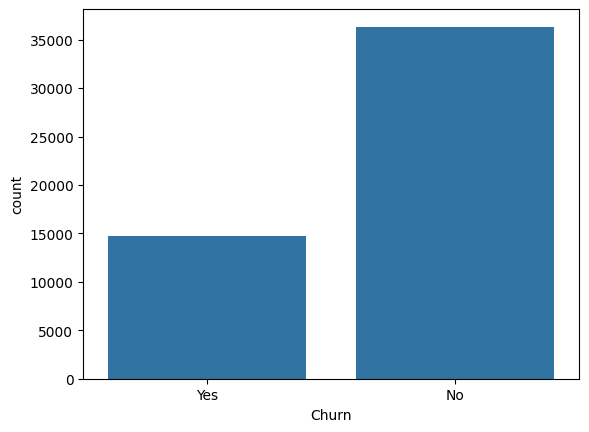

In [13]:
sns.countplot(x=target_column, data=df)
plt.show()

In [14]:
list_categorical_columns.remove(target_column)

In [15]:
# unique column check
df[list_categorical_columns].nunique().sort_values()

NonUSTravel                      2
MadeCallToRetentionTeam          2
OwnsMotorcycle                   2
ChildrenInHH                     2
HandsetRefurbished               2
HandsetWebCapable                2
TruckOwner                       2
RVOwner                          2
Homeownership                    2
BuysViaMailOrder                 2
RespondsToMailOffers             2
OptOutMailings                   2
NotNewCellphoneUser              2
OwnsComputer                     2
HasCreditCard                    2
NewCellphoneUser                 2
MaritalStatus                    3
PrizmCode                        4
CreditRating                     7
Occupation                       8
IncomeGroup                     10
ReferralsMadeBySubscriber       13
HandsetModels                   13
ServiceArea                    747
CustomerID                   51047
dtype: int64

In [16]:
# Drop CustomerID
df = df.drop(["CustomerID"], axis=1)
list_categorical_columns.remove("CustomerID")

In [17]:
df[list_categorical_columns].isna().sum().sort_values(ascending=False)

ServiceArea                  24
HandsetModels                 1
Occupation                    0
PrizmCode                     0
CreditRating                  0
MadeCallToRetentionTeam       0
OwnsMotorcycle                0
IncomeGroup                   0
ReferralsMadeBySubscriber     0
NotNewCellphoneUser           0
NewCellphoneUser              0
HasCreditCard                 0
OwnsComputer                  0
NonUSTravel                   0
OptOutMailings                0
RespondsToMailOffers          0
BuysViaMailOrder              0
Homeownership                 0
RVOwner                       0
TruckOwner                    0
HandsetWebCapable             0
HandsetRefurbished            0
ChildrenInHH                  0
MaritalStatus                 0
dtype: int64

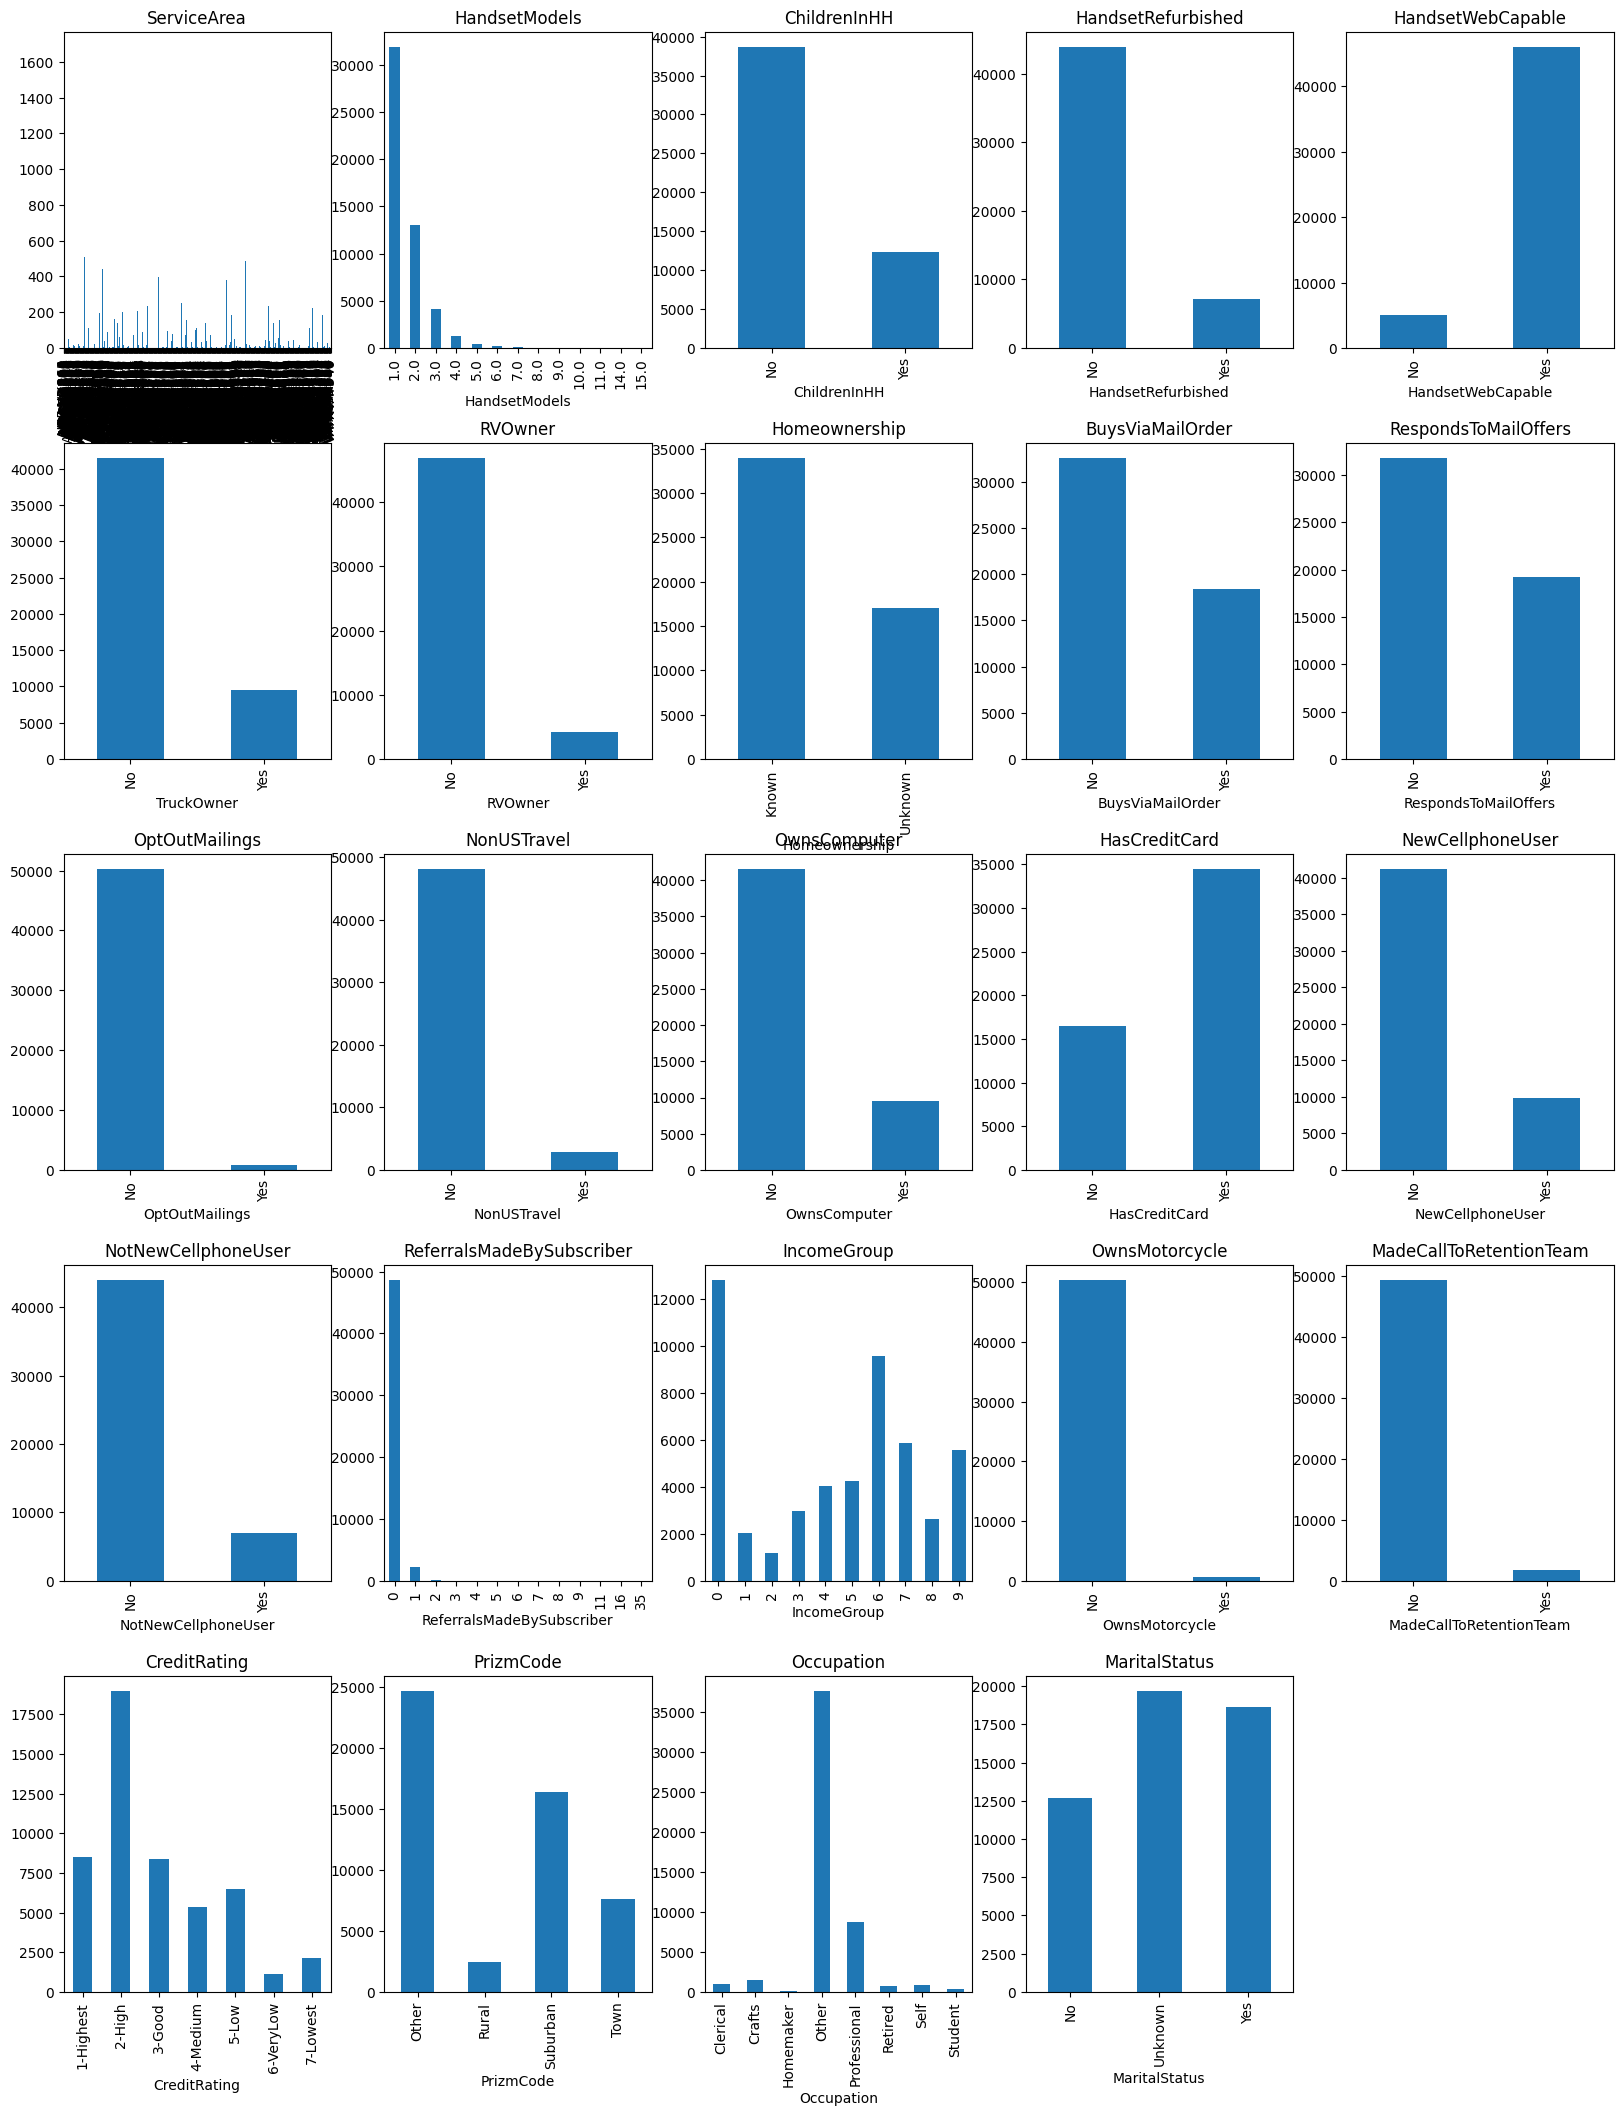

In [18]:
# cateogircla column 별 분포 확인 
plt.figure(figsize=(20,20))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.3, wspace=0.2)
for column_name in list_categorical_columns:
    plt.subplot(5,5,x)
    x = x+1
    df[column_name].value_counts().sort_index().plot(kind='bar')
    plt.title(column_name)
plt.show()

In [19]:
df["ServiceArea"].nunique()

747

In [25]:
column_name = "MonthsInService"
target_column = "Churn"

pd.crosstab(df[column_name], df[target_column])

Churn,No,Yes
MonthsInService,,
6,602,144
7,2389,432
8,1862,352
9,2104,373
10,1867,514
11,1993,1606
12,1638,1099
13,1818,901
14,1522,769


More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


<Figure size 3000x3000 with 0 Axes>

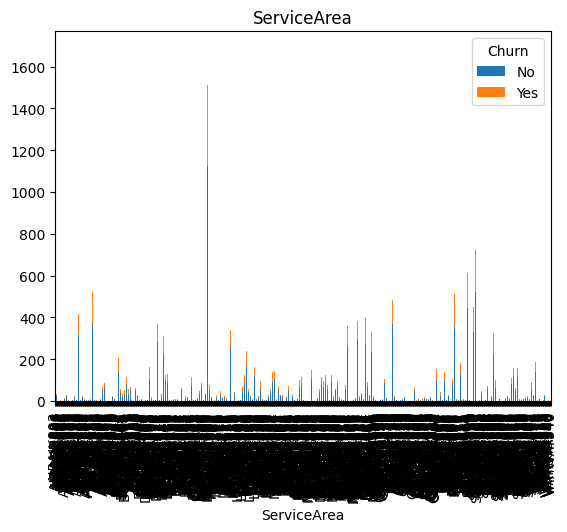

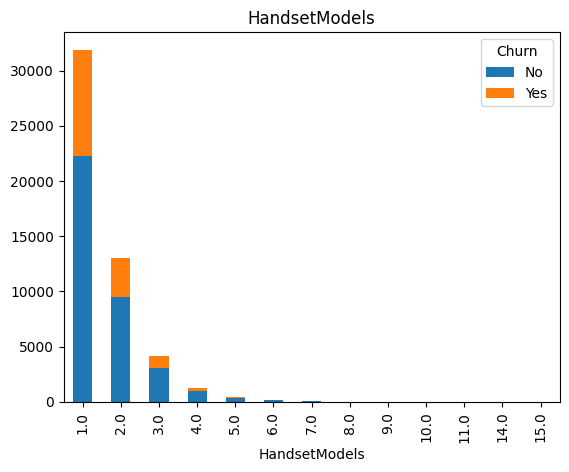

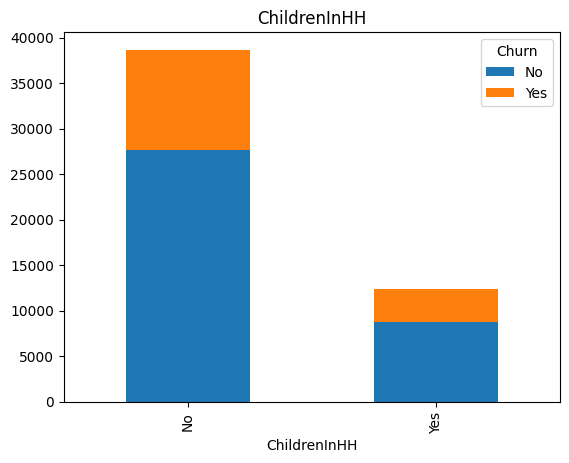

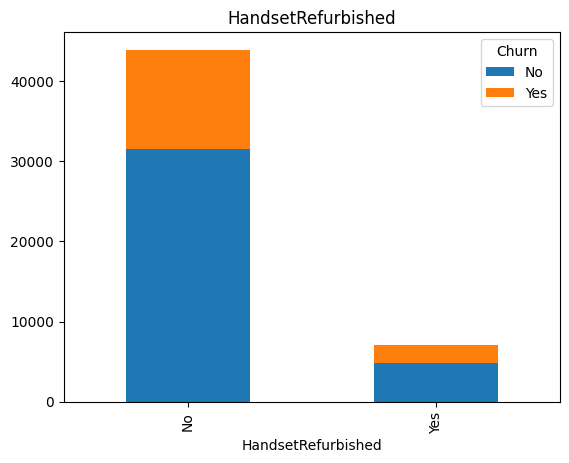

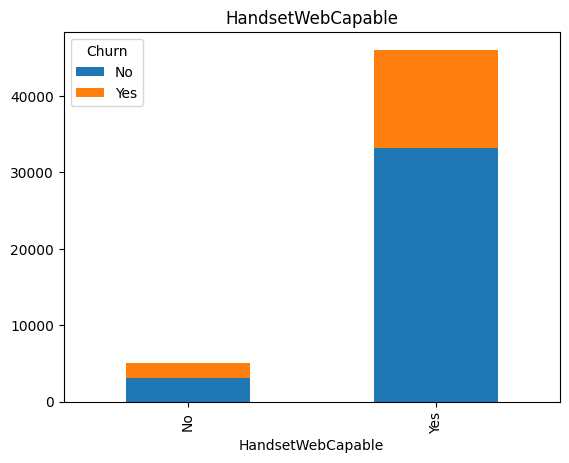

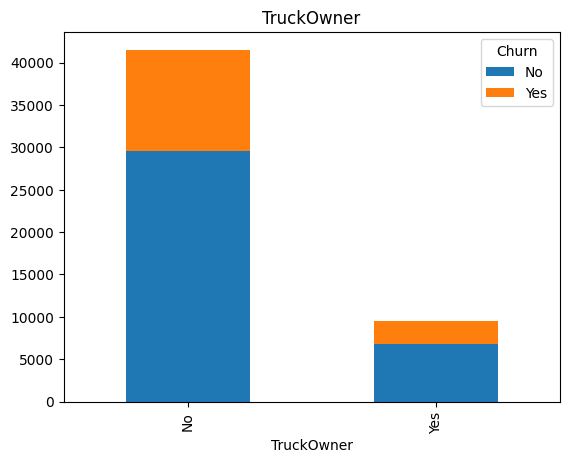

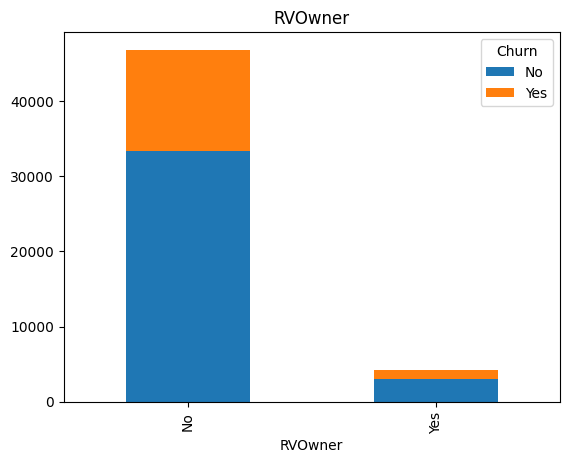

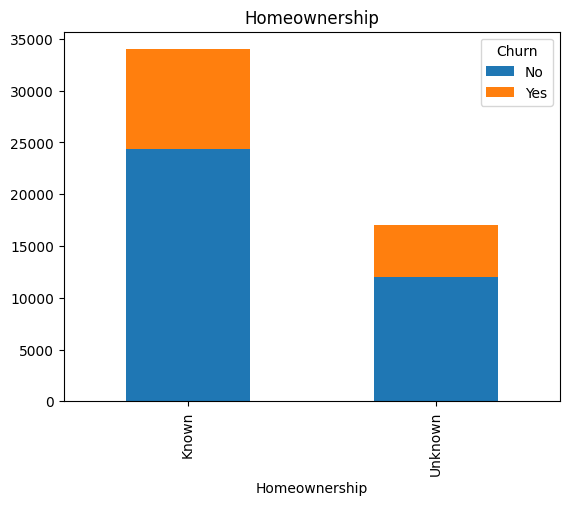

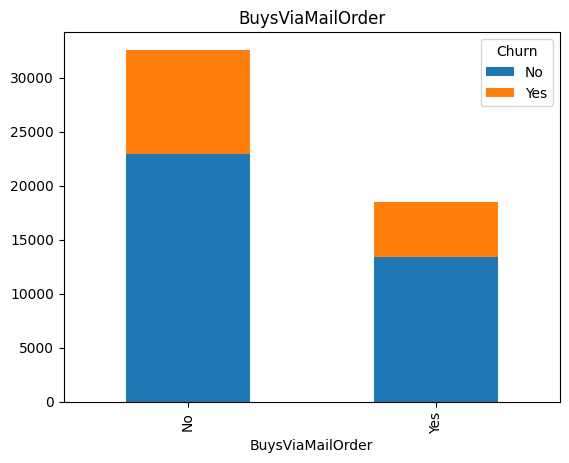

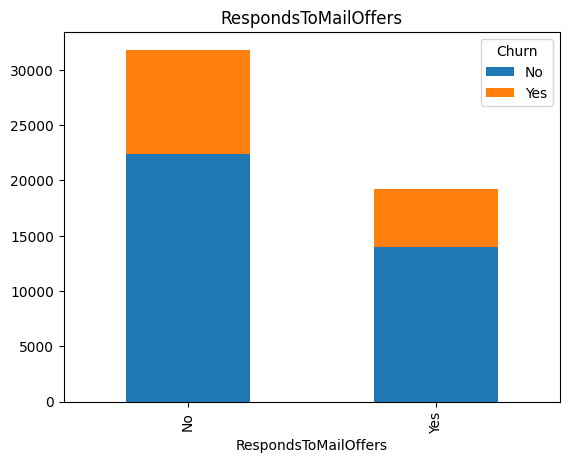

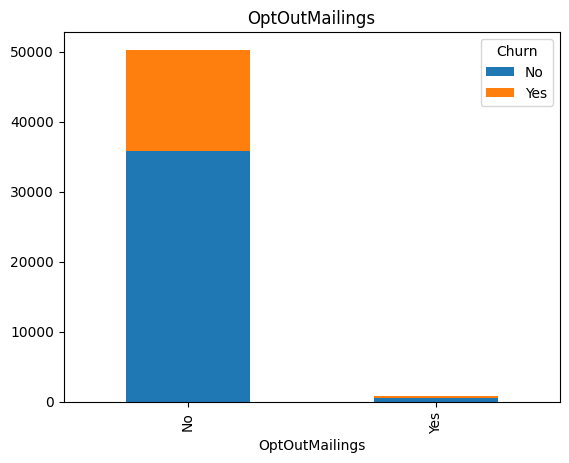

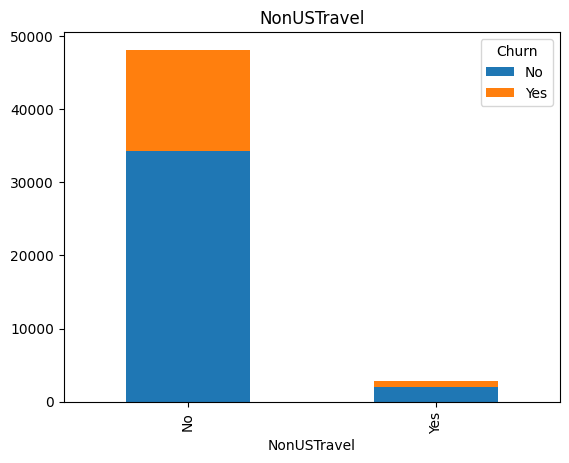

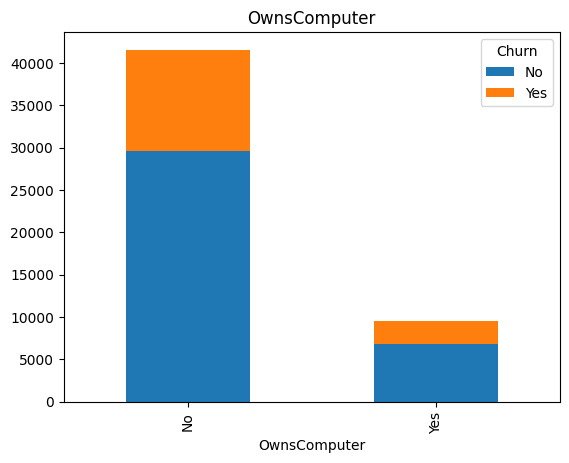

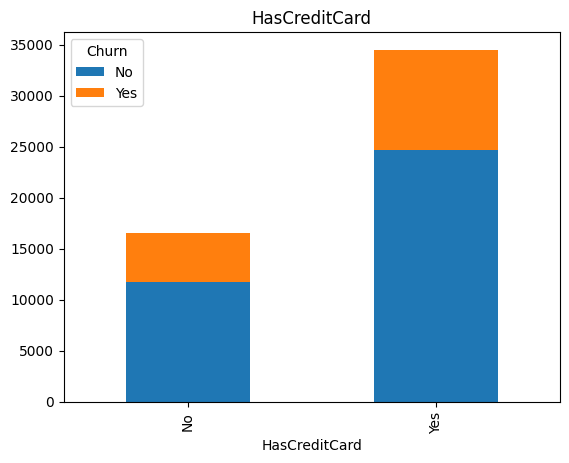

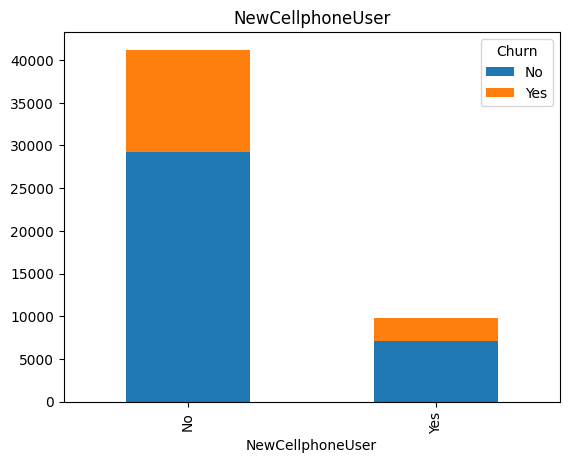

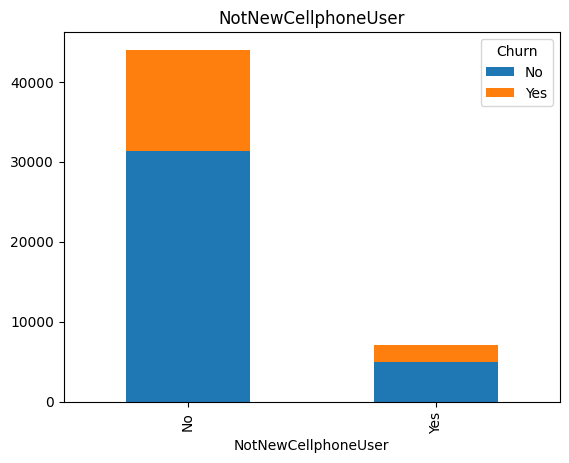

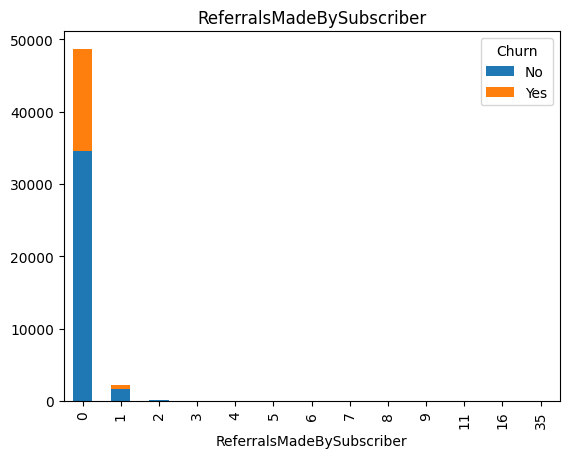

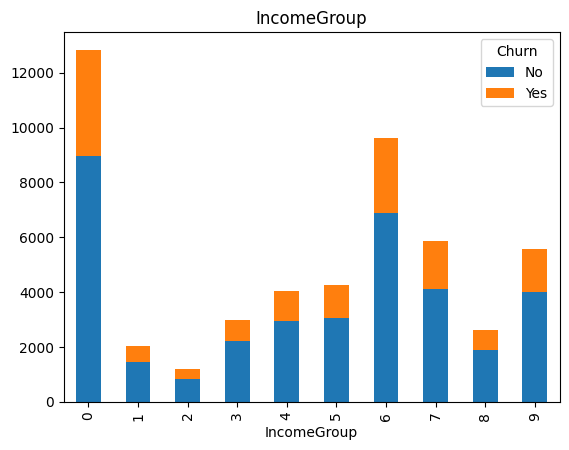

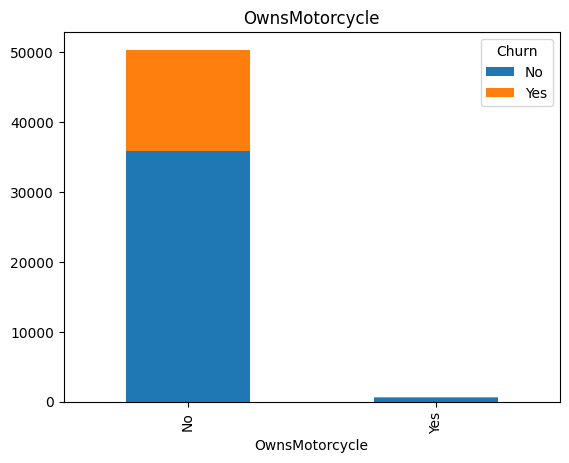

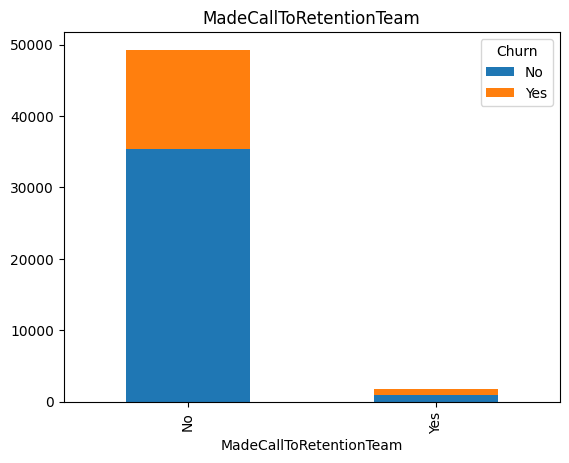

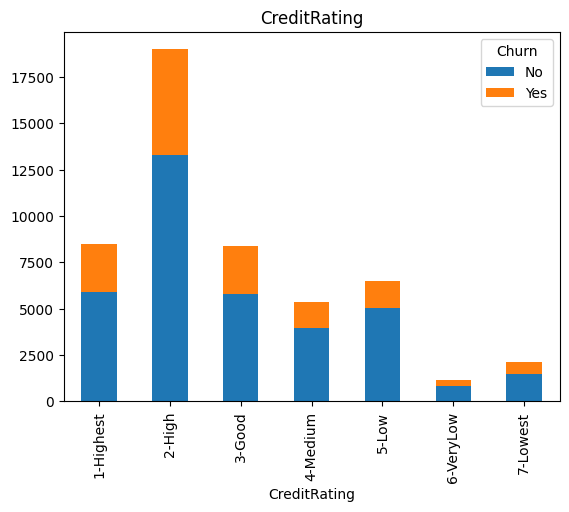

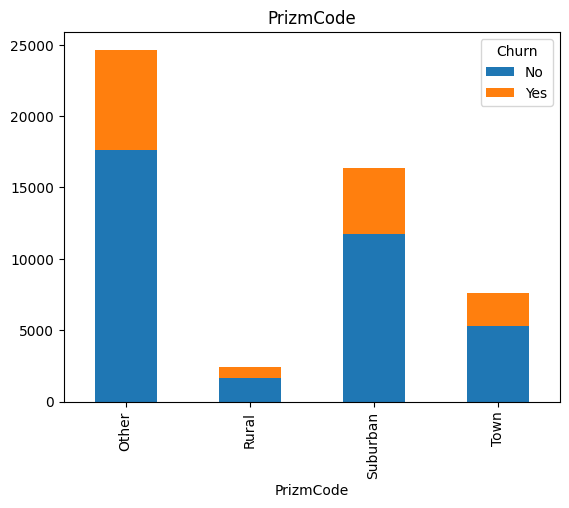

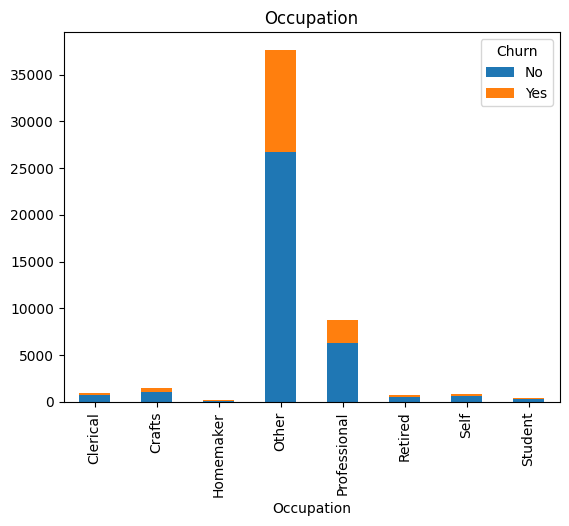

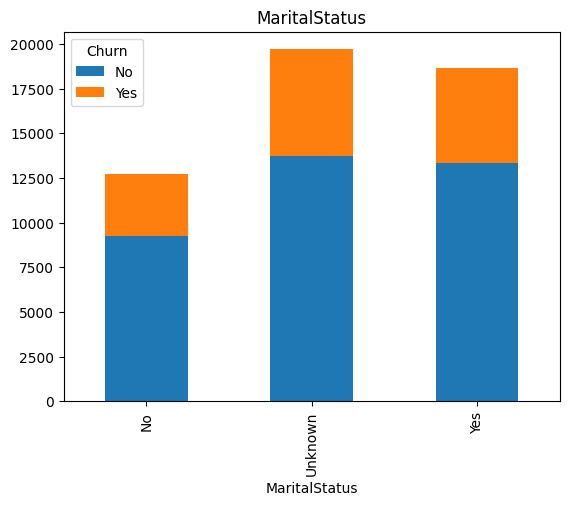

In [21]:
# categorical column과 dependent data(target column) 분포 분석
plt.figure(figsize=(30,30))
x = 1
for column_name in list_categorical_columns:
    pd.crosstab(df[column_name], df[target_column]).plot(kind="bar", stacked=True)
    plt.title(column_name)
plt.show()

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


<Figure size 3000x3000 with 0 Axes>

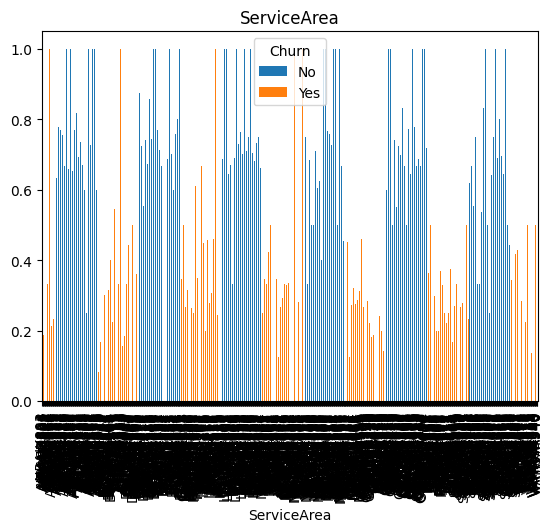

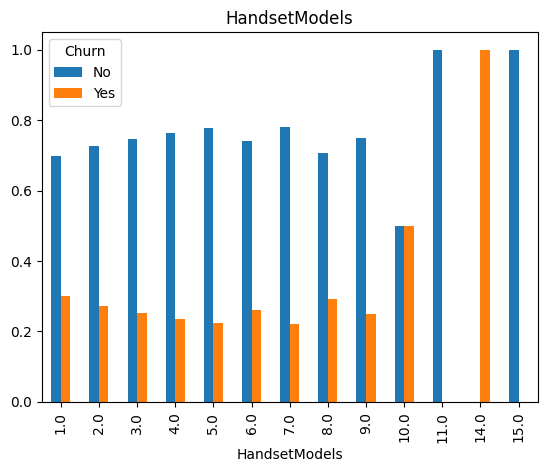

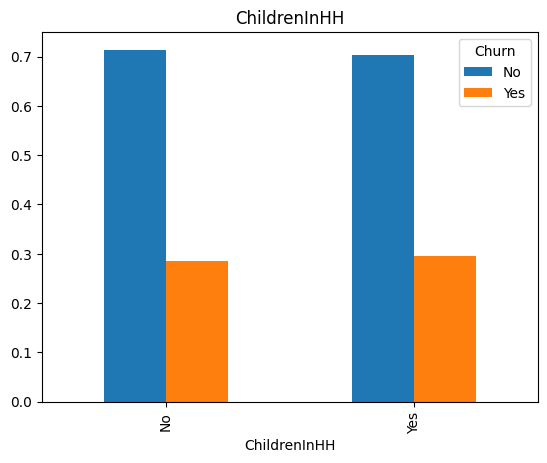

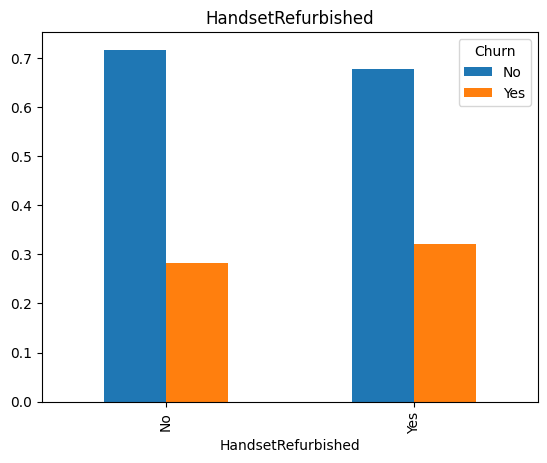

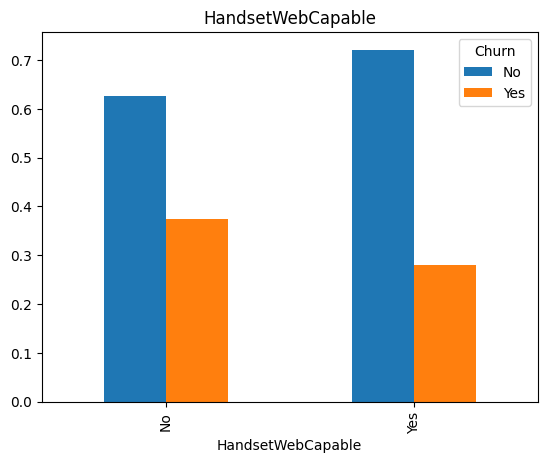

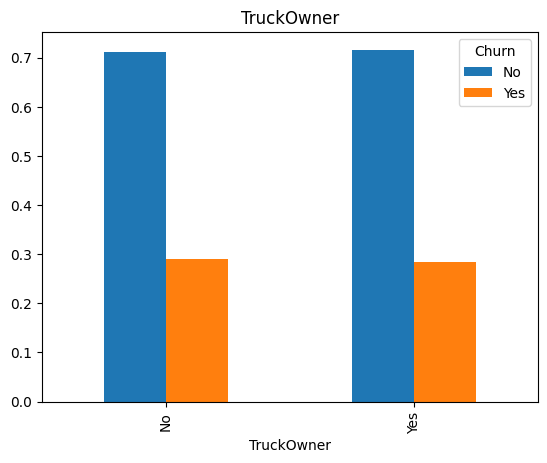

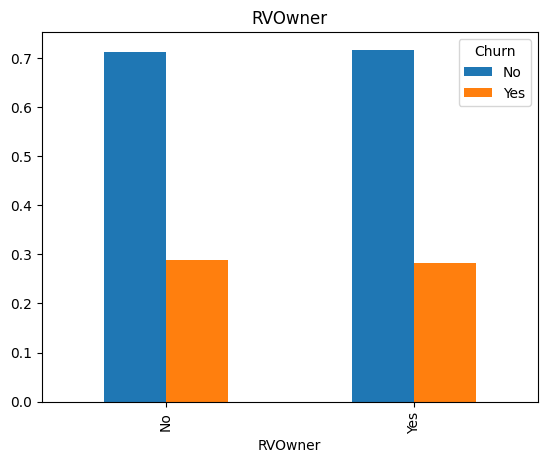

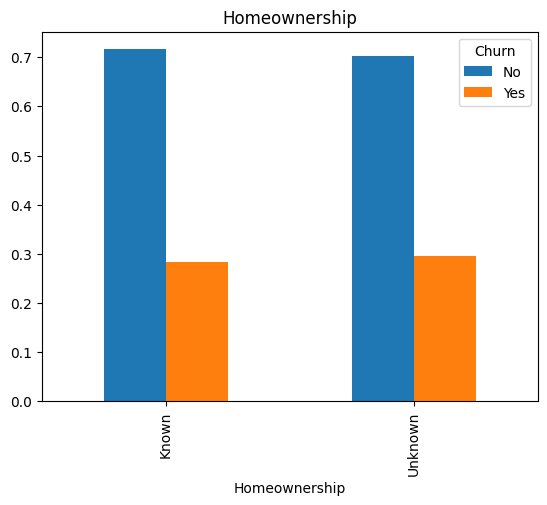

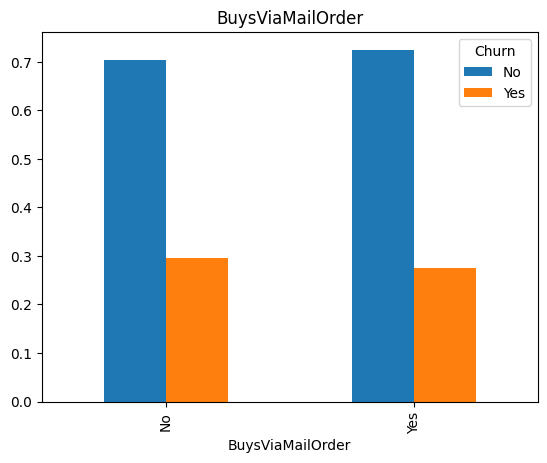

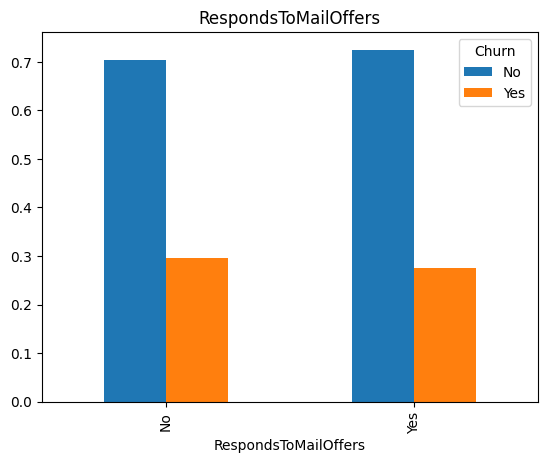

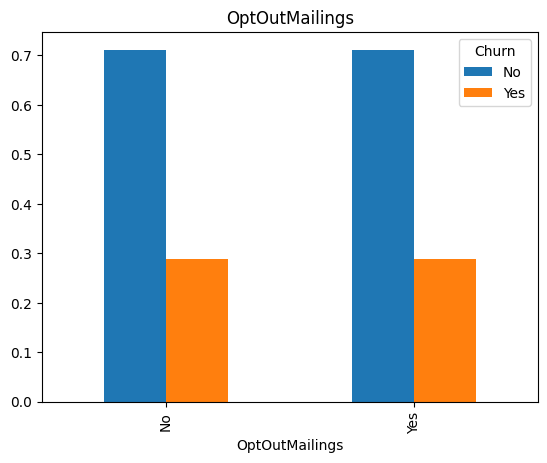

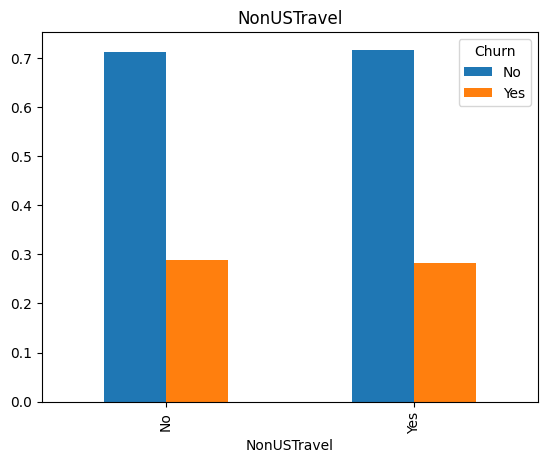

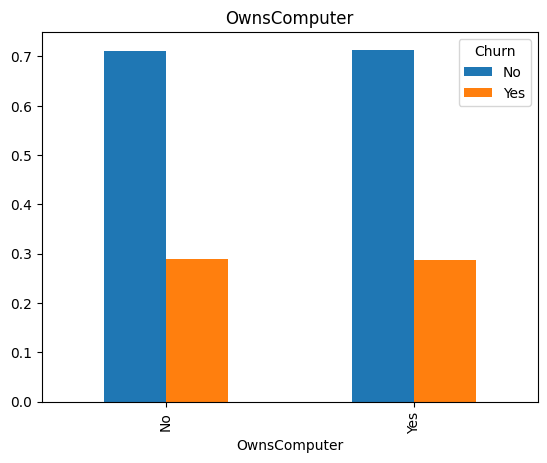

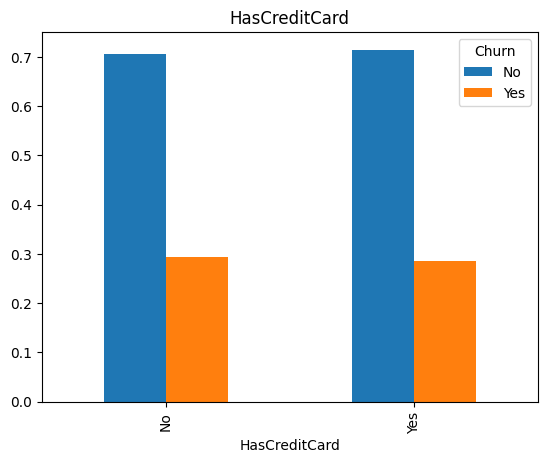

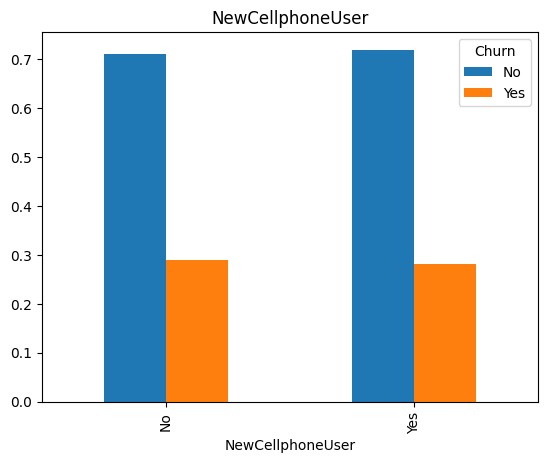

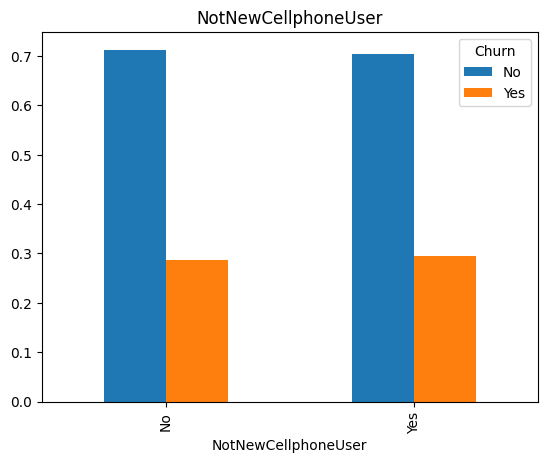

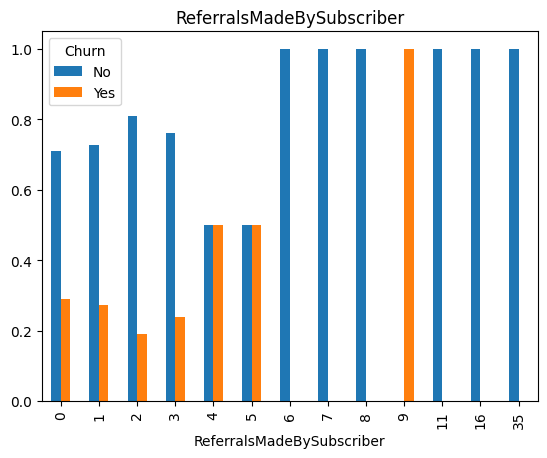

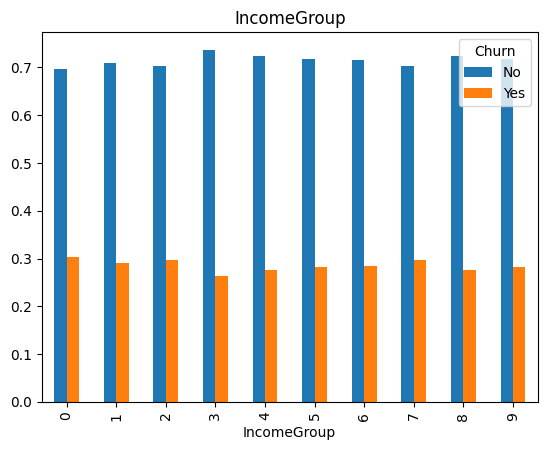

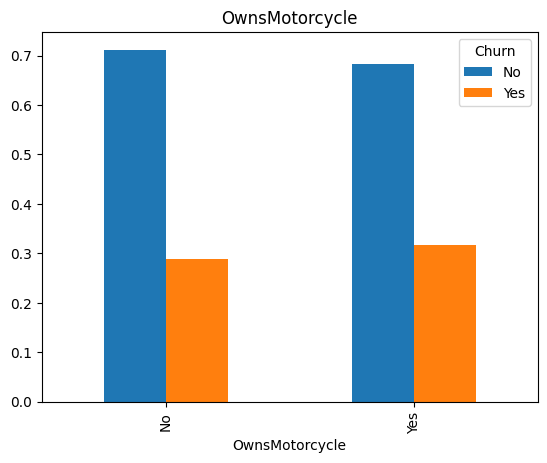

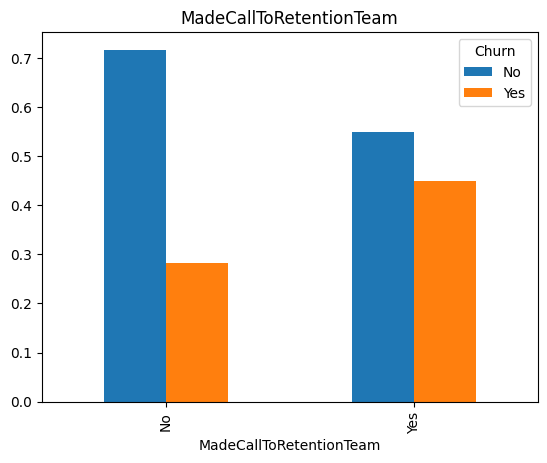

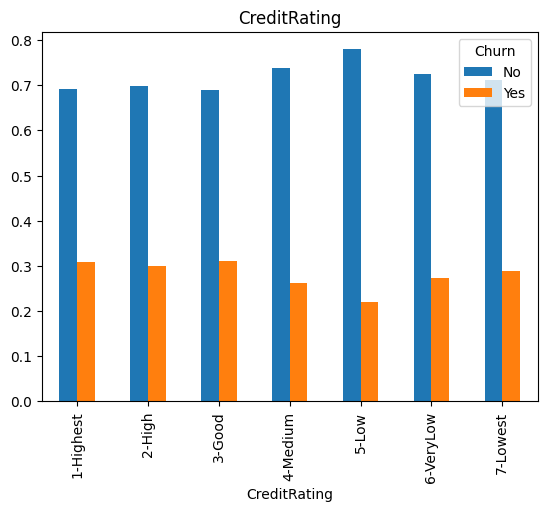

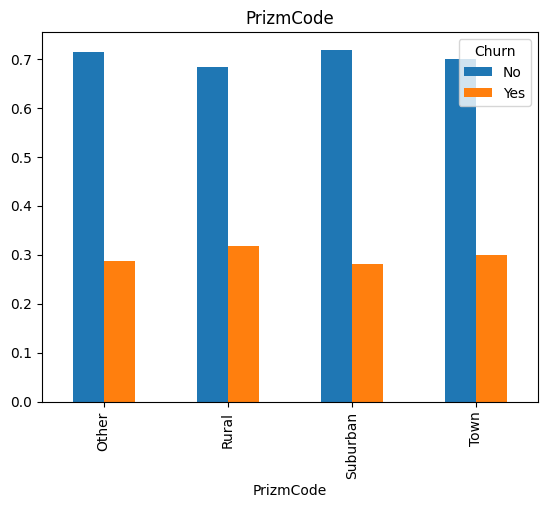

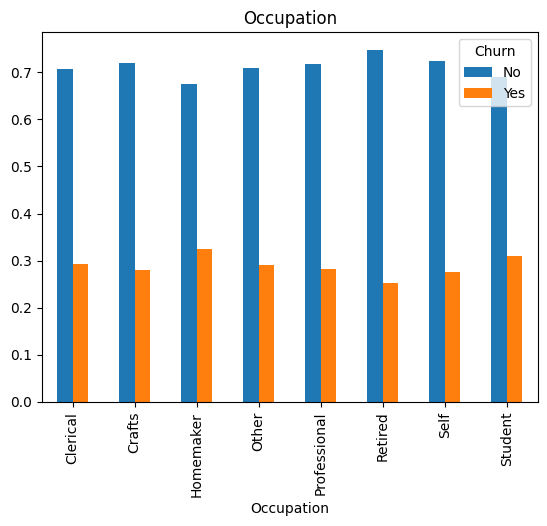

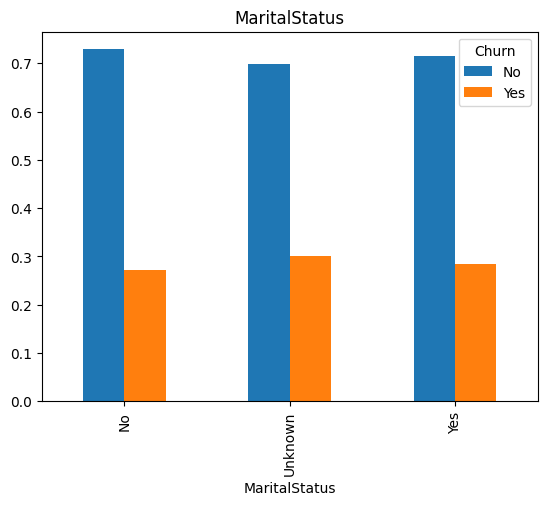

In [ ]:
# categorical column과 dependent data(target column) 분포 분석
plt.figure(figsize=(30,30))
x = 1
#plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.8, wspace=0.2)
for column_name in list_categorical_columns:
    pd.crosstab(df[column_name], df[target_column], normalize="index").plot(kind="bar")
    plt.title(column_name)
plt.show()

In [23]:
list_meaningful_column_by_chi = []
# 카이제곱 검정
for column_name in list_categorical_columns:
  statistic, pvalue, _, _ = chi2_contingency(pd.crosstab(df[target_column], df[column_name]))
  if pvalue <= 0.05:
    list_meaningful_column_by_chi.append(column_name)
  print(column_name, statistic, pvalue)

print("all categorical columns : ", len(list_categorical_columns))
print("selected categorical columns by chi : ", len(list_meaningful_column_by_chi), list_meaningful_column_by_chi)


ServiceArea 959.1341950534099 1.8626092067707354e-07
HandsetModels 101.54186704979912 2.775843217291745e-16
ChildrenInHH 4.61817626131507 0.03163485621782633
HandsetRefurbished 45.59520482835272 1.4539708879836166e-11
HandsetWebCapable 196.37325683591058 1.2921230309851365e-44
TruckOwner 1.157607227658802 0.28196233363643325
RVOwner 0.5815606024210445 0.44570126395061915
Homeownership 8.78331422999254 0.003039983689868538
BuysViaMailOrder 23.99339787075113 9.666660453552875e-07
RespondsToMailOffers 26.688591338952175 2.39028676982069e-07
OptOutMailings 0.0 1.0
NonUSTravel 0.41381302347756754 0.5200404823729523
OwnsComputer 0.20230034253271137 0.6528704477893238
HasCreditCard 3.7511355407084417 0.0527716490589044
NewCellphoneUser 2.9794627566804435 0.0843272591287213
NotNewCellphoneUser 2.26747448311423 0.13211504086572767
ReferralsMadeBySubscriber 16.21312134428997 0.1816685664418549
IncomeGroup 31.88523845163498 0.00020843103577175245
OwnsMotorcycle 2.5777673584025007 0.10837442421561

In [24]:
df[list_numeric_columns].nunique().sort_values()

RetentionOffersAccepted          4
RetentionCalls                   5
ActiveSubs                      12
AdjustmentsToCreditRating       15
UniqueSubs                      15
Handsets                        23
CallForwardingCalls             31
AgeHH2                          43
AgeHH1                          43
MonthsInService                 56
ThreewayCalls                   78
DirectorAssistedCalls          146
CustomerCareCalls              185
TotalRecurringCharge           214
CallWaitingCalls               223
DroppedCalls                   285
BlockedCalls                   373
DroppedBlockedCalls            447
InboundCalls                   472
RoamingCalls                   530
OverageMinutes                 746
OutboundCalls                  787
UnansweredCalls                840
CurrentEquipmentDays          1438
OffPeakCallsInOut             1669
PeakCallsInOut                1839
PercChangeMinutes             2262
MonthlyMinutes                2719
PercChangeRevenues  

In [26]:
# pandas' describe 기능을 활용하여 데이터 확인
# df[list_numeric_columns].describe().to_csv("data/describe.csv")
pd.read_csv("data/describe.csv")

,Unnamed: 0,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,...,MonthsInService,UniqueSubs,ActiveSubs,Handsets,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,AdjustmentsToCreditRating
0,count,50891.000000,50891.000000,50891.000000,50891.000000,50891.000000,50891.000000,50680.000000,50680.000000,51047.000000,...,51047.000000,51047.000000,51047.000000,51046.000000,51046.000000,50138.000000,50138.000000,51047.000000,51047.000000,51047.000000
1,mean,58.834492,525.653416,46.830088,0.895229,40.027785,1.236244,-11.547908,-1.191985,6.011489,...,18.756264,1.532157,1.354340,1.805646,380.545841,31.338127,21.144142,0.037201,0.018277,0.053911
2,std,44.507336,529.871063,23.848871,2.228546,96.588076,9.818294,257.514772,39.574915,9.043955,...,9.800138,1.223384,0.675477,1.331173,253.801982,22.094635,23.931368,0.206483,0.142458,0.383147
3,min,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,0.000000,...,6.000000,1.000000,0.000000,1.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,33.610000,158.000000,30.000000,0.000000,0.000000,0.000000,-83.000000,-7.100000,0.700000,...,11.000000,1.000000,1.000000,1.000000,205.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,48.460000,366.000000,45.000000,0.250000,3.000000,0.000000,-5.000000,-0.300000,3.000000,...,16.000000,1.000000,1.000000,1.000000,329.000000,36.000000,0.000000,0.000000,0.000000,0.000000
6,75%,71.065000,723.000000,60.000000,0.990000,41.000000,0.300000,66.000000,1.600000,7.700000,...,24.000000,2.000000,2.000000,2.000000,515.000000,48.000000,42.000000,0.000000,0.000000,0.000000
7,max,1223.380000,7359.000000,400.000000,159.390000,4321.000000,1112.400000,5192.000000,2483.500000,221.700000,...,61.000000,196.000000,53.000000,24.000000,1812.000000,99.000000,99.000000,4.000000,3.000000,25.000000


In [26]:
len_total = len(df)
for column_name in list_numeric_columns:
    len_zero = len(df[df[column_name]==0])
    print("%s : %d -> %.2f"%(column_name, len_zero, len_zero/len_total*100))

MonthlyRevenue : 6 -> 0.01
MonthlyMinutes : 723 -> 1.42
TotalRecurringCharge : 160 -> 0.31
DirectorAssistedCalls : 24512 -> 48.02
OverageMinutes : 23262 -> 45.57
RoamingCalls : 34947 -> 68.46
PercChangeMinutes : 1124 -> 2.20
PercChangeRevenues : 5818 -> 11.40
DroppedCalls : 7738 -> 15.16
BlockedCalls : 13912 -> 27.25
UnansweredCalls : 4990 -> 9.78
CustomerCareCalls : 28020 -> 54.89
ThreewayCalls : 37133 -> 72.74
ReceivedCalls : 6337 -> 12.41
OutboundCalls : 6428 -> 12.59
InboundCalls : 14999 -> 29.38
PeakCallsInOut : 4224 -> 8.27
OffPeakCallsInOut : 4547 -> 8.91
DroppedBlockedCalls : 5793 -> 11.35
CallForwardingCalls : 50813 -> 99.54
CallWaitingCalls : 25029 -> 49.03
MonthsInService : 0 -> 0.00
UniqueSubs : 0 -> 0.00
ActiveSubs : 39 -> 0.08
Handsets : 0 -> 0.00
CurrentEquipmentDays : 22 -> 0.04
AgeHH1 : 13917 -> 27.26
AgeHH2 : 26087 -> 51.10
RetentionCalls : 49302 -> 96.58
RetentionOffersAccepted : 50166 -> 98.27
AdjustmentsToCreditRating : 49209 -> 96.40


In [27]:
list_removed_by_describe = ["CallForwardingCalls", "RetentionCalls","RetentionOffersAccepted","ReferralsMadeBySubscriber"]

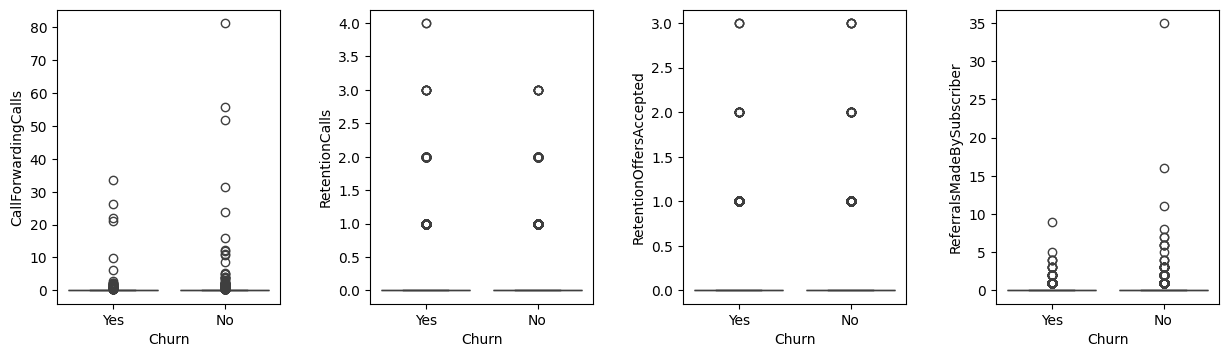

In [28]:
plt.figure(figsize=(15,3))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.2, wspace=0.4)
for column_name in list_removed_by_describe:
    plt.subplot(1,4,x)
    x = x + 1
    sns.boxplot(data=df,x=target_column,y=column_name)
plt.show()

In [29]:
# kruskall 검정
list_kruskall_test = []

for column_name in list_removed_by_describe:
  list_by_value = []
  for value in df[target_column].dropna().unique():
      df_tmp = df[df[target_column] == value][column_name].dropna()
      list_by_value.append(np.array(df_tmp))
  statistic, pvalue = kruskal(*list_by_value)
  if pvalue <= 0.05:
    list_kruskall_test.append(column_name)
  print(column_name, ", ",statistic,", ", pvalue)
print("all categorical columns : ", len(list_removed_by_describe))
print("selected columns by kruskal : ", len(list_kruskall_test), list_kruskall_test)

CallForwardingCalls ,  1.1604177899438202 ,  0.2813789113336678
RetentionCalls ,  231.87180917712158 ,  2.3288378576836346e-52
RetentionOffersAccepted ,  65.82285494662723 ,  4.933283124854033e-16
ReferralsMadeBySubscriber ,  4.824808197178692 ,  0.028052986265473638
all categorical columns :  4
selected columns by kruskal :  3 ['RetentionCalls', 'RetentionOffersAccepted', 'ReferralsMadeBySubscriber']


In [30]:
df = df.drop(["CallForwardingCalls"], axis=1)
list_numeric_columns.remove("CallForwardingCalls")

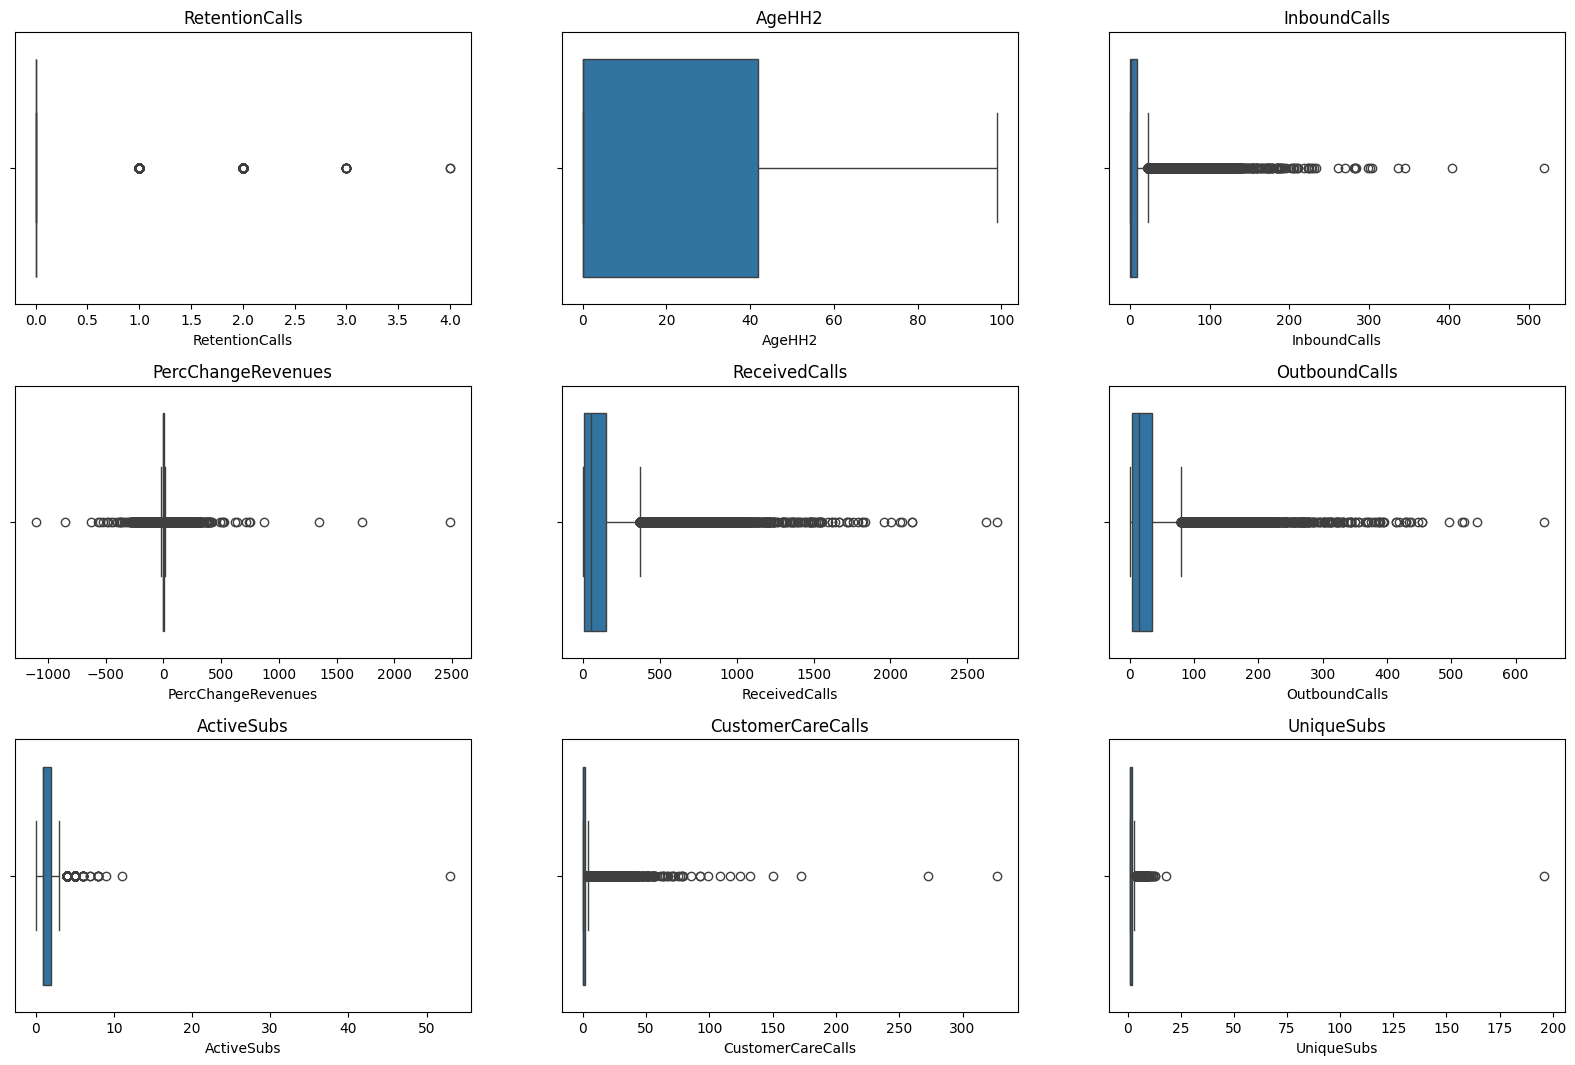

In [31]:
list_numerical_column_randomly = random.sample(list_numeric_columns, 9)
plt.figure(figsize=(20,10))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.3, wspace=0.2)
for column_name in list_numerical_column_randomly:
    plt.subplot(3,3,x)
    x = x+1
    sns.boxplot(x=column_name, data=df)
    plt.title(column_name)
plt.show()

In [32]:
df[list_numeric_columns].isna().sum().sort_values(ascending=False)

AgeHH2                       909
AgeHH1                       909
PercChangeMinutes            367
PercChangeRevenues           367
MonthlyRevenue               156
TotalRecurringCharge         156
DirectorAssistedCalls        156
OverageMinutes               156
RoamingCalls                 156
MonthlyMinutes               156
CurrentEquipmentDays           1
Handsets                       1
ActiveSubs                     0
UniqueSubs                     0
RetentionCalls                 0
CallWaitingCalls               0
RetentionOffersAccepted        0
MonthsInService                0
InboundCalls                   0
DroppedBlockedCalls            0
OffPeakCallsInOut              0
PeakCallsInOut                 0
OutboundCalls                  0
ReceivedCalls                  0
ThreewayCalls                  0
CustomerCareCalls              0
UnansweredCalls                0
BlockedCalls                   0
DroppedCalls                   0
AdjustmentsToCreditRating      0
dtype: int

In [33]:
# knn inputer fit_transofrm
imputer = KNNImputer(n_neighbors=3)
fillna_data = imputer.fit_transform(df[list_numeric_columns])

df.loc[:, list_numeric_columns] = fillna_data

In [34]:
df[list_numeric_columns].isna().sum().sort_values(ascending=False)

MonthlyRevenue               0
MonthlyMinutes               0
RetentionOffersAccepted      0
RetentionCalls               0
AgeHH2                       0
AgeHH1                       0
CurrentEquipmentDays         0
Handsets                     0
ActiveSubs                   0
UniqueSubs                   0
MonthsInService              0
CallWaitingCalls             0
DroppedBlockedCalls          0
OffPeakCallsInOut            0
PeakCallsInOut               0
InboundCalls                 0
OutboundCalls                0
ReceivedCalls                0
ThreewayCalls                0
CustomerCareCalls            0
UnansweredCalls              0
BlockedCalls                 0
DroppedCalls                 0
PercChangeRevenues           0
PercChangeMinutes            0
RoamingCalls                 0
OverageMinutes               0
DirectorAssistedCalls        0
TotalRecurringCharge         0
AdjustmentsToCreditRating    0
dtype: int64

In [35]:
for column_name in list_numeric_columns:
  print(column_name, "skew : ", skew(df[column_name]), "kur : ", kurtosis(df[column_name]))
  
# 추후 scaling을 활용한 feature preprocessing의 필요성 확인

MonthlyRevenue skew :  4.1797775425447865 kur :  40.98811804294872
MonthlyMinutes skew :  2.1952692824361564 kur :  8.116153203882767
TotalRecurringCharge skew :  1.6282078124299881 kur :  8.896589135483339
DirectorAssistedCalls skew :  13.567504244882914 kur :  599.6539103358488
OverageMinutes skew :  8.11857397298183 kur :  158.25061430491715
RoamingCalls skew :  57.94899088464107 kur :  5162.970590217787
PercChangeMinutes skew :  -0.32505298085127554 kur :  20.93954210416633
PercChangeRevenues skew :  7.892844253858725 kur :  454.9655650111449
DroppedCalls skew :  4.549088677567483 kur :  41.72828840454181
BlockedCalls skew :  9.79016654357725 kur :  168.2756056154945
UnansweredCalls skew :  4.381101399517268 kur :  40.950335312535174
CustomerCareCalls skew :  14.235494960848984 kur :  577.5963648091017
ThreewayCalls skew :  17.552544625402547 kur :  604.134442002215
ReceivedCalls skew :  3.1155816736145825 kur :  16.20828523240733
OutboundCalls skew :  3.525575392326984 kur :  22.4

<Axes: >

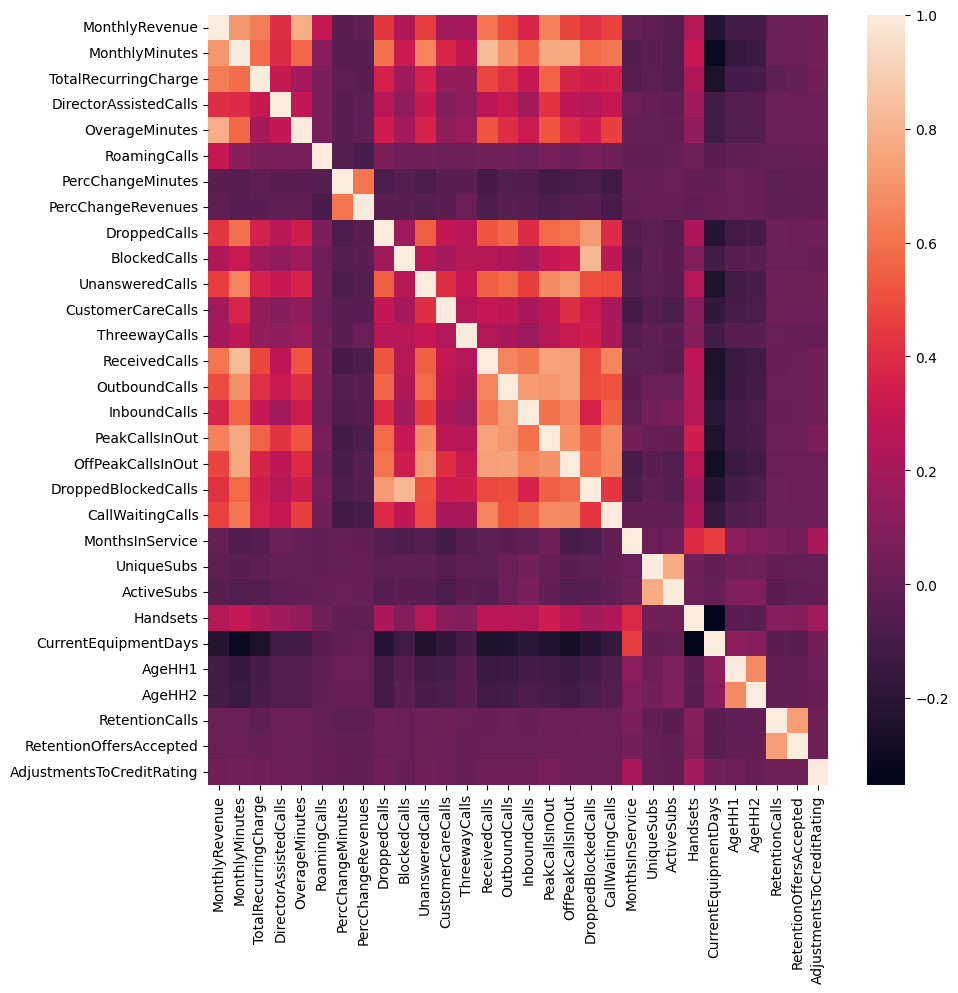

In [36]:
df_corr = df[list_numeric_columns].corr()
plt.figure(figsize=(10,10))
sns.heatmap(df_corr)

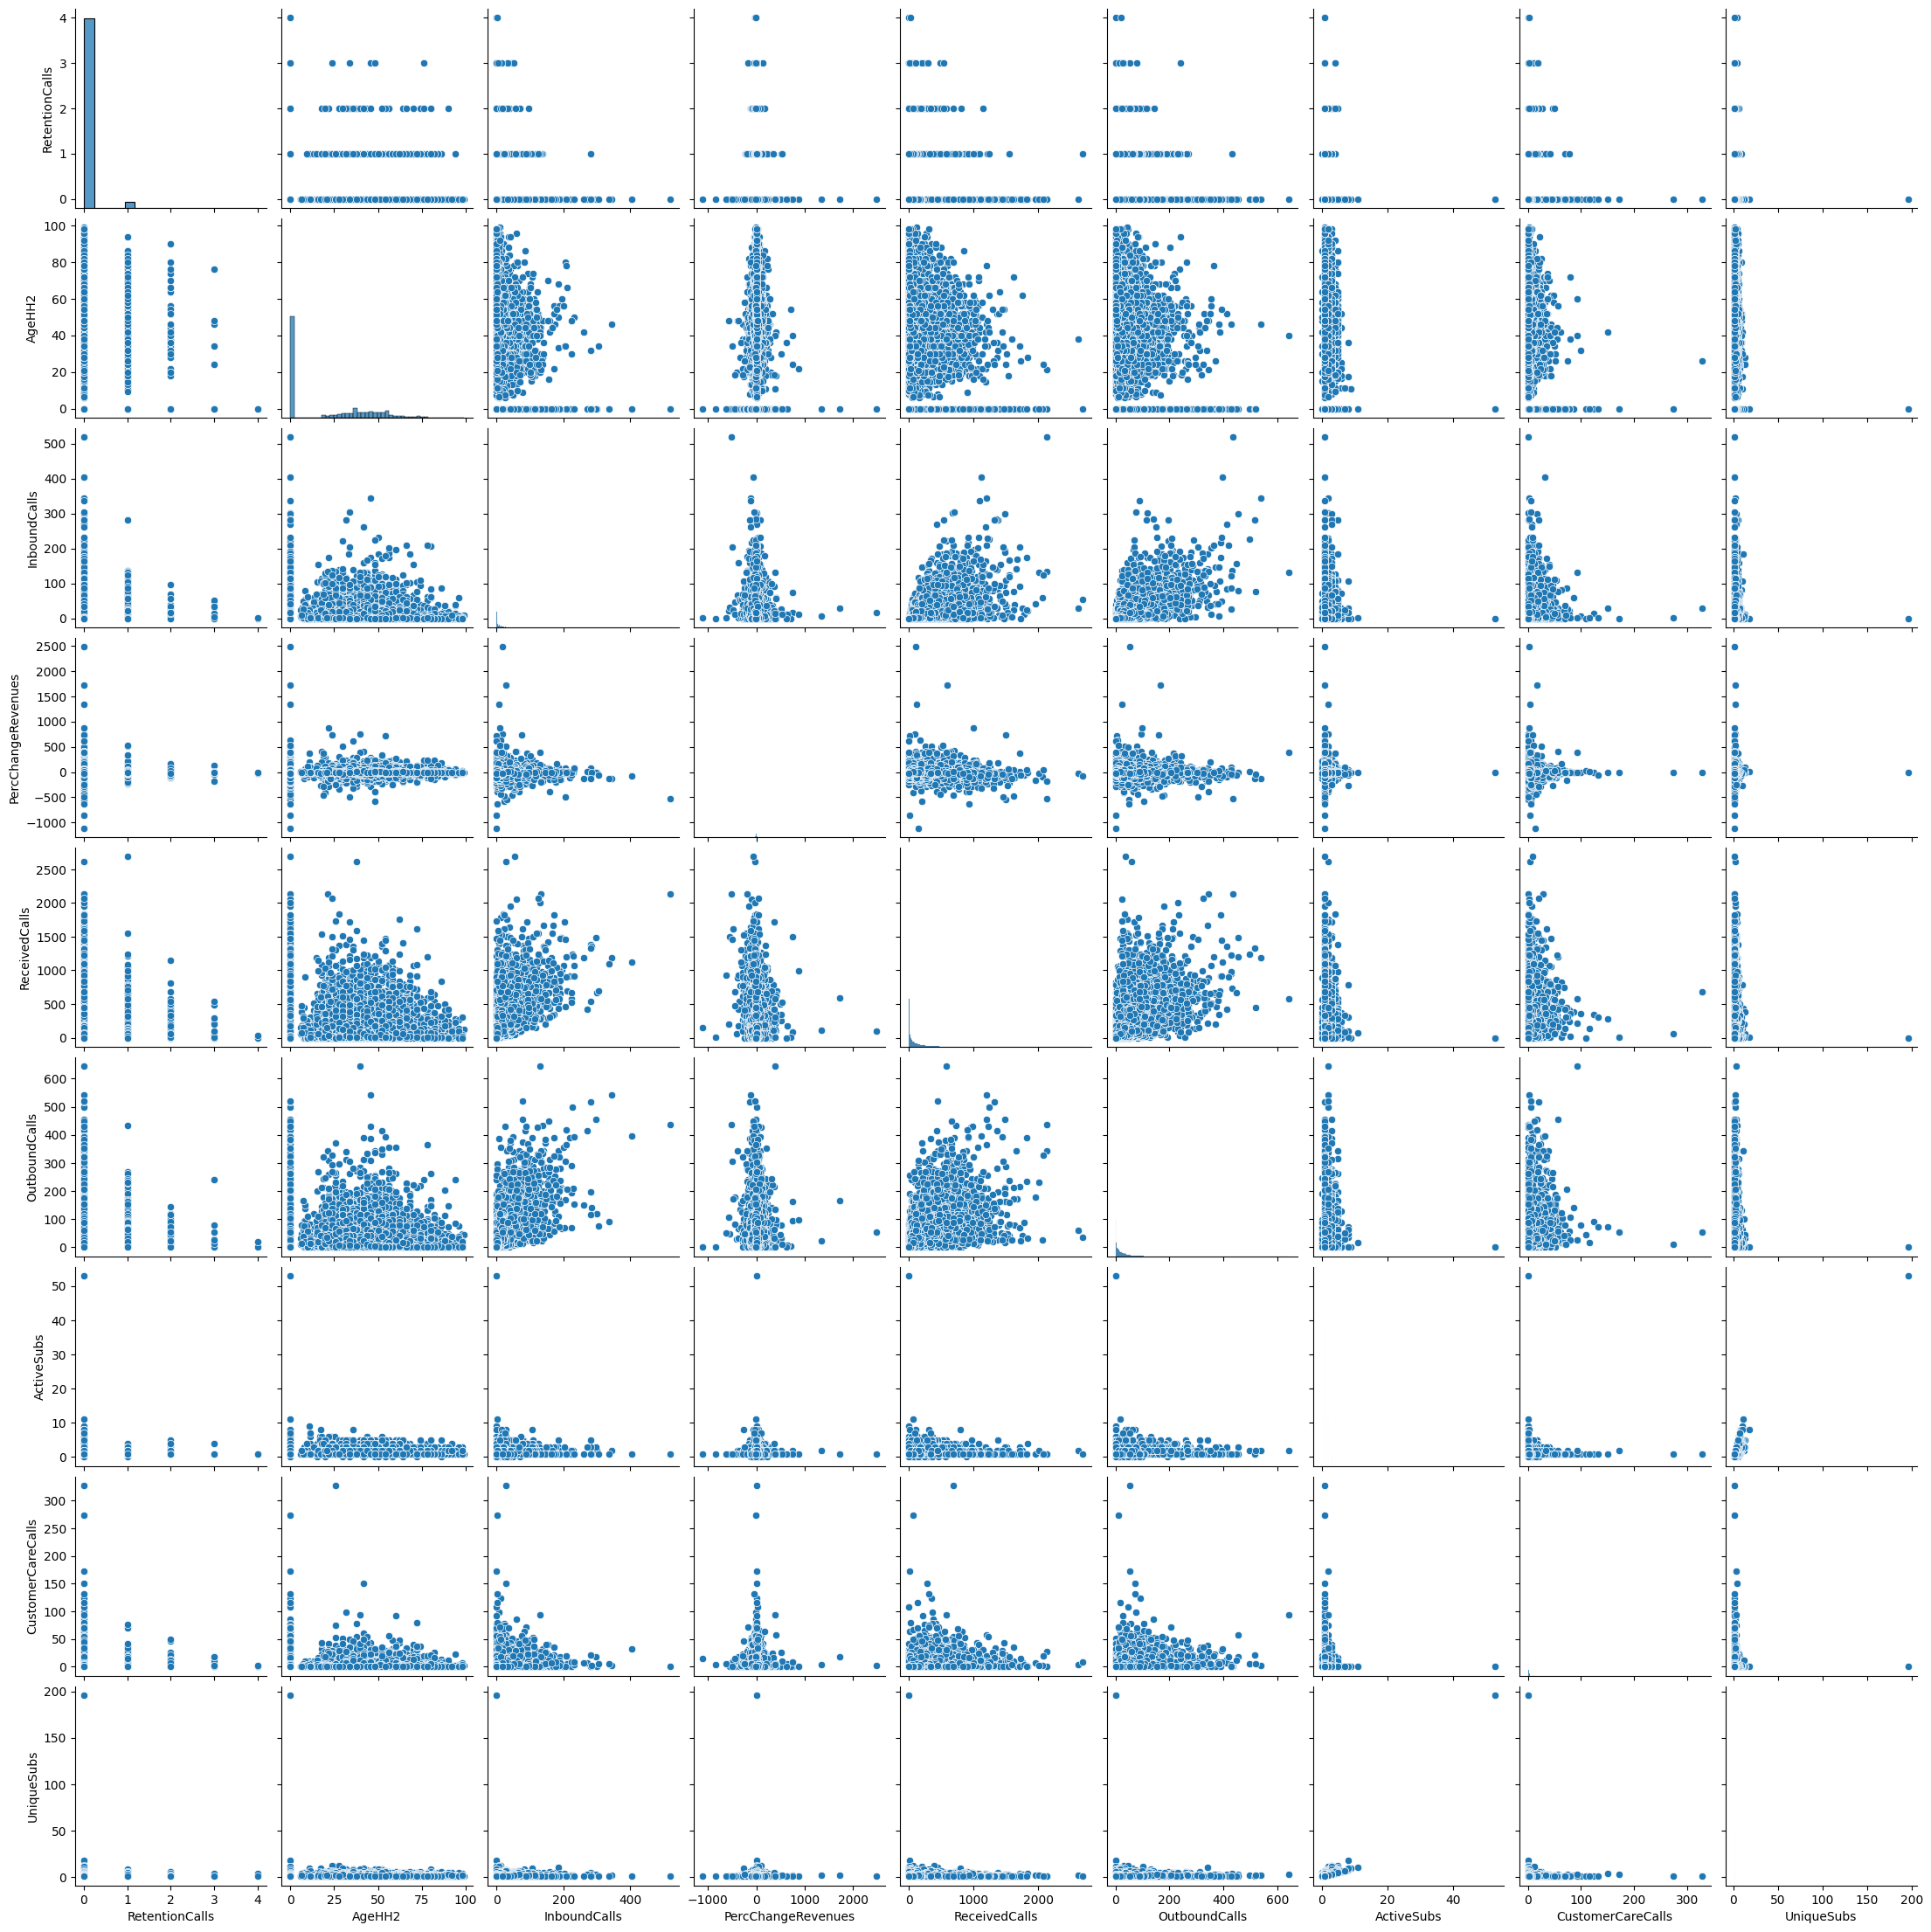

In [37]:
sns.pairplot(data=df.loc[:, list_numerical_column_randomly])

In [38]:
print(df_corr.loc["OverageMinutes","PeakCallsInOut"])
print(df_corr.loc["PeakCallsInOut","TotalRecurringCharge"])

0.519320928641495
0.5529887110674058


In [39]:
index_corr_over_80 = np.where((abs(df_corr) > 0.8) & (df_corr != 1))
index_corr_over_80

(array([ 1,  9, 13, 18], dtype=int64), array([13, 18,  1,  9], dtype=int64))

In [40]:
len_corr_over_80 = len(index_corr_over_80[0])
left_columns = df_corr.columns[index_corr_over_80[0]]
right_columns = df_corr.columns[index_corr_over_80[1]]
for index in range(len_corr_over_80):
  print(left_columns[index], "<->", right_columns[index])  

MonthlyMinutes <-> ReceivedCalls
BlockedCalls <-> DroppedBlockedCalls
ReceivedCalls <-> MonthlyMinutes
DroppedBlockedCalls <-> BlockedCalls


In [41]:
# correlation이 0.8 이상인 경우의 pvalue 검정
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html
list_not_valid = []
for index in range(len_corr_over_80):
    statistic, pvalue = stats.pearsonr(df.loc[:,left_columns[index]], df.loc[:,right_columns[index]])
    print("%s<->%s : %f %f"%(left_columns[index],right_columns[index] , statistic, pvalue))
    if (pvalue > 0.05):
        list_not_valid.append(column_name)
print("end")
print(len(list_not_valid), " is not valids")

MonthlyMinutes<->ReceivedCalls : 0.829127 0.000000
BlockedCalls<->DroppedBlockedCalls : 0.816328 0.000000
ReceivedCalls<->MonthlyMinutes : 0.829127 0.000000
DroppedBlockedCalls<->BlockedCalls : 0.816328 0.000000
end
0  is not valids


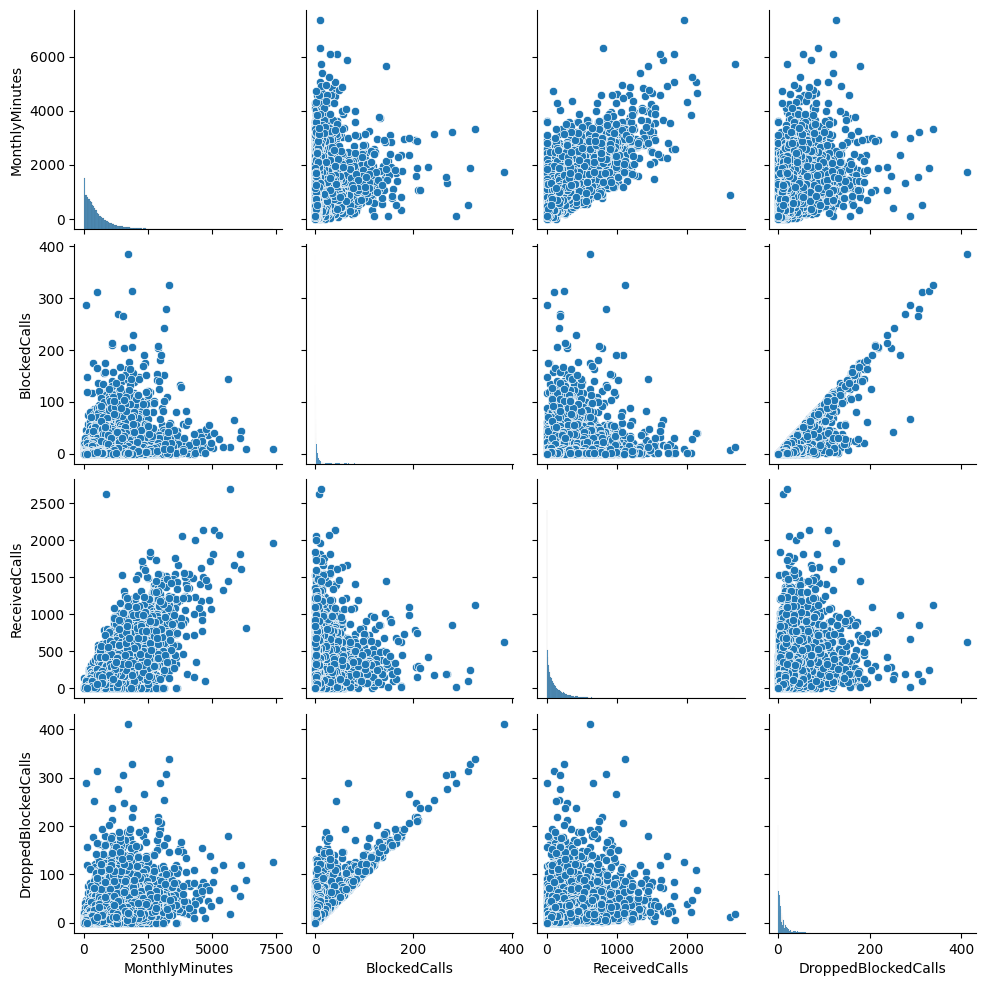

In [42]:
# 한 번 더 scatter plot을 보면서 눈으로 검정. 제거할 지 여부를 판단
sns.pairplot(data=df.loc[:, left_columns])

In [43]:
list_removed_by_correlation = ["MonthlyMinutes", "BlockedCalls"]

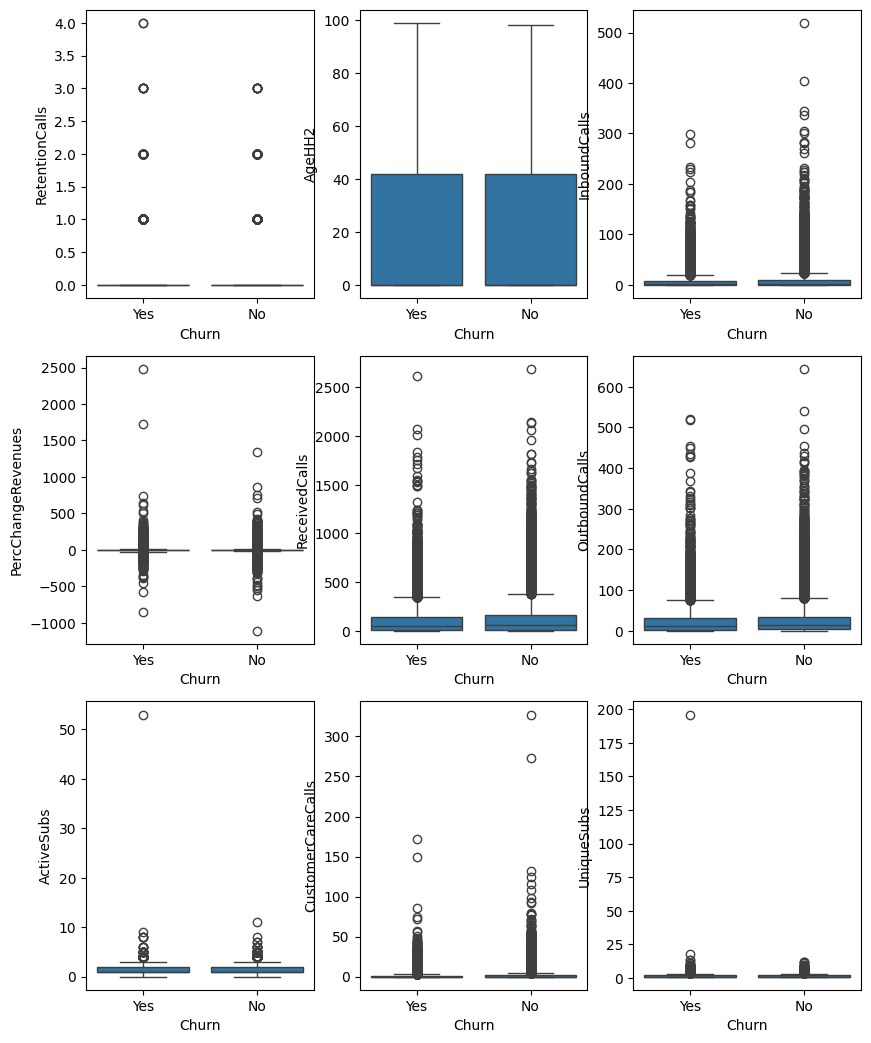

In [44]:
plt.figure(figsize=(10,10))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.2, wspace=0.2)
for column_name in list_numerical_column_randomly:
    plt.subplot(3,3,x)
    x = x + 1
    sns.boxplot(data=df,x=target_column,y=column_name)
plt.show()

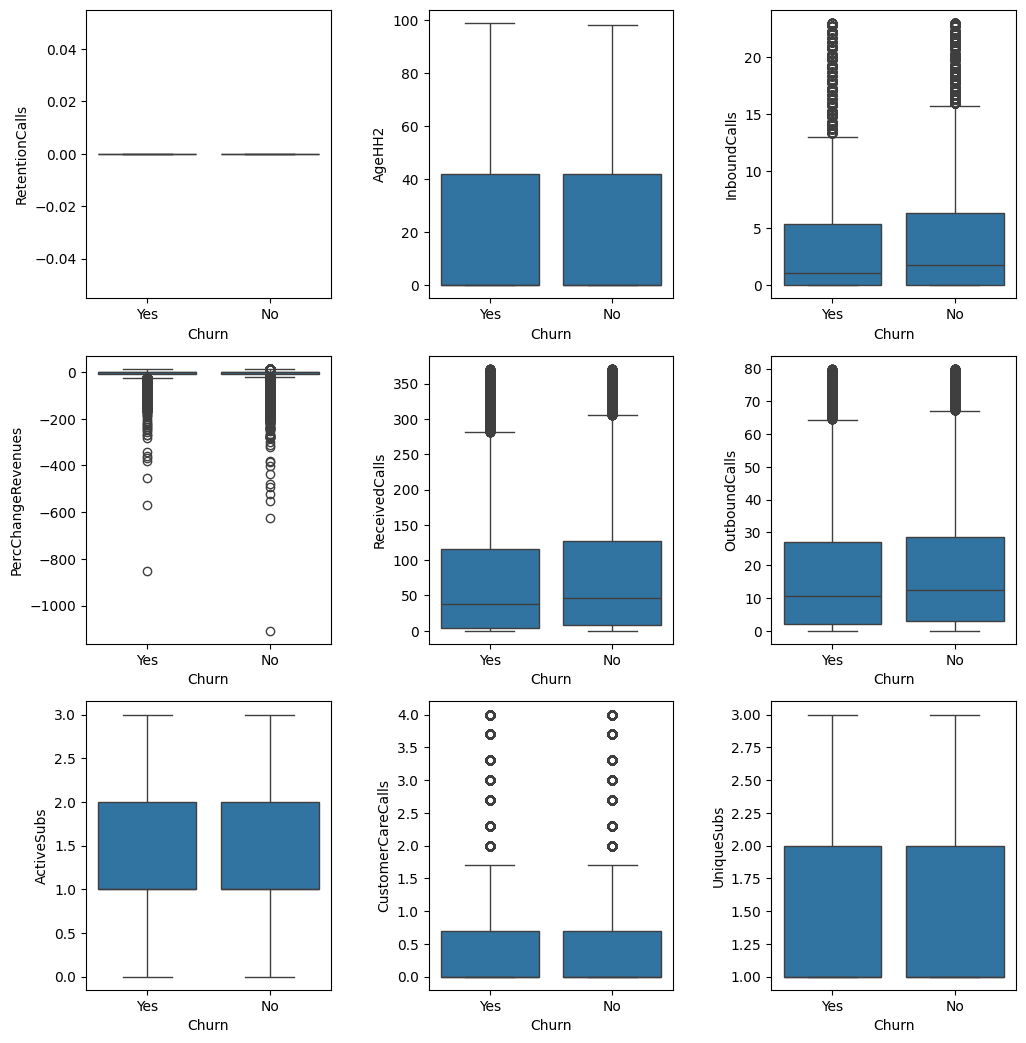

In [45]:
# 정확한 분포 확인이 어려우므로, 특정 condition을 부여한 뒤에 boxplot을 다시 관측
# Maximum IQR boundary를 활용
def get_maximum_iqr_boundary(df):
  iqr = df.quantile(0.75) - df.quantile(0.25)
  return df.quantile(0.75) + 1.5*iqr

plt.figure(figsize=(12,10))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.2, wspace=0.4)
for column_name in list_numerical_column_randomly:
    plt.subplot(3,3,x)
    x = x + 1
    sns.boxplot(data=df[df[column_name] <= get_maximum_iqr_boundary(df[column_name])],x=target_column,y=column_name)
plt.show()

In [46]:
list_column_normality = []
df_check_norm = df.dropna().copy()
for column_name in list_numeric_columns:
  statistic, pvalue = stats.shapiro(df_check_norm[column_name])
  if pvalue > 0.05:
    list_column_normality.append(column_name)
  print(column_name, ", statistic : ", statistic, ". pvalue : ", pvalue)

print("정규성 만족하는 column 수 : ", len(list_column_normality))

MonthlyRevenue , statistic :  0.7145478906100631 . pvalue :  1.0014333198512079e-125
MonthlyMinutes , statistic :  0.8059282217439047 . pvalue :  7.023507626339755e-115
TotalRecurringCharge , statistic :  0.9064809675072635 . pvalue :  1.0214075920721684e-95
DirectorAssistedCalls , statistic :  0.3994370293397701 . pvalue :  4.908787415681527e-148
OverageMinutes , statistic :  0.43320455073223385 . pvalue :  3.1114658723753654e-146
RoamingCalls , statistic :  0.08060355201474478 . pvalue :  1.2205796857481046e-161
PercChangeMinutes , statistic :  0.8049803601554707 . pvalue :  5.160552632290639e-115
PercChangeRevenues , statistic :  0.5764780584830125 . pvalue :  2.493690720276322e-137
DroppedCalls , statistic :  0.620720712322419 . pvalue :  4.945600939274487e-134
BlockedCalls , statistic :  0.34989337713508295 . pvalue :  1.6012787742255756e-150
UnansweredCalls , statistic :  0.6520398634074382 . pvalue :  1.744466188169265e-131
CustomerCareCalls , statistic :  0.37261260135134433 . 

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 51022.


In [47]:
list_meaningful_column_by_kruskall = []
list_value = df[target_column].unique()

for column_name in list_numeric_columns:
  list_by_quality_value = []
  for quality_value in list_value:
      df_tmp = df[df[target_column] == quality_value][column_name].dropna()
      list_by_quality_value.append(np.array(df_tmp))
  statistic, pvalue = kruskal(*list_by_quality_value)
  if pvalue <= 0.05:
    list_meaningful_column_by_kruskall.append(column_name)
  print(column_name, ", ",statistic,", ", pvalue)
print("all numerical columns : ", len(list_numeric_columns))
print("selected columns by kruskall : ", len(list_meaningful_column_by_kruskall), list_meaningful_column_by_kruskall)

MonthlyRevenue ,  30.722902974444757 ,  2.9763120497162824e-08
MonthlyMinutes ,  205.74525470419042 ,  1.1645951255649207e-46
TotalRecurringCharge ,  233.92560084119924 ,  8.303577808340257e-53
DirectorAssistedCalls ,  33.14681180863245 ,  8.545637824129027e-09
OverageMinutes ,  18.278344717267736 ,  1.9086459498884583e-05
RoamingCalls ,  0.02783757774127133 ,  0.8674912466970017
PercChangeMinutes ,  120.0576588880877 ,  6.144842604278736e-28
PercChangeRevenues ,  0.8094829087552577 ,  0.3682731730390518
DroppedCalls ,  34.730429994021975 ,  3.7866613476914504e-09
BlockedCalls ,  15.534602164540589 ,  8.10087691118151e-05
UnansweredCalls ,  109.29197716050999 ,  1.4005801099078922e-25
CustomerCareCalls ,  138.2748183576532 ,  6.345812925076679e-32
ThreewayCalls ,  49.93593973334415 ,  1.5884827360048233e-12
ReceivedCalls ,  116.48750444432348 ,  3.7171386805781585e-27
OutboundCalls ,  106.89435830311126 ,  4.695434183697914e-25
InboundCalls ,  158.7159182544562 ,  2.1587959353600066e-3

In [48]:
df_fs = df[list_meaningful_column_by_chi + list_meaningful_column_by_kruskall].drop(list_removed_by_correlation,errors='ignore',axis=1)
df_fs.head(2)

,ServiceArea,HandsetModels,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,Homeownership,BuysViaMailOrder,RespondsToMailOffers,IncomeGroup,MadeCallToRetentionTeam,...,MonthsInService,UniqueSubs,ActiveSubs,Handsets,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,AdjustmentsToCreditRating
0,SEAPOR503,2.0,No,No,Yes,Known,Yes,Yes,4,Yes,...,61,2,1,2.0,361.0,62.0,0.0,1,0,0
1,PITHOM412,1.0,Yes,No,No,Known,Yes,Yes,5,No,...,58,1,1,2.0,1504.0,40.0,42.0,0,0,0


In [49]:
list_categorical_columns = list(df_fs.select_dtypes(include=['object']).columns)
list_numeric_columns = list(df_fs.select_dtypes(include=['float64', 'int64']).columns)
print("final categorical columns : ",len(list_categorical_columns))
print("final numerical columns : ",len(list_numeric_columns))

final categorical columns :  13
final numerical columns :  26


In [50]:
Y = df[target_column]
X_fs = df_fs

In [51]:
Y

0        Yes
1        Yes
2         No
3         No
4        Yes
        ... 
51042    Yes
51043     No
51044    Yes
51045     No
51046     No
Name: Churn, Length: 51047, dtype: object

In [52]:
# label encoding 
le_encoder = LabelEncoder()
le_encoder.fit(Y)
Y_encoded = le_encoder.transform(Y)
Y_encoded

array([1, 1, 0, ..., 1, 0, 0])

In [53]:
X_fs.head(2)

,ServiceArea,HandsetModels,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,Homeownership,BuysViaMailOrder,RespondsToMailOffers,IncomeGroup,MadeCallToRetentionTeam,...,MonthsInService,UniqueSubs,ActiveSubs,Handsets,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,AdjustmentsToCreditRating
0,SEAPOR503,2.0,No,No,Yes,Known,Yes,Yes,4,Yes,...,61,2,1,2.0,361.0,62.0,0.0,1,0,0
1,PITHOM412,1.0,Yes,No,No,Known,Yes,Yes,5,No,...,58,1,1,2.0,1504.0,40.0,42.0,0,0,0


In [54]:
scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
X_fs.loc[:, list_numeric_columns] = minmax_scaler.fit_transform(scaler.fit_transform(X_fs[list_numeric_columns]))
X_fs.head(2)

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1.         0.94545455 0.98181818 ... 0.34545455 0.45454545 0.34545455]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.00512821 0.         0.         ... 0.         0.         0.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.01886792 0.01886792 0.01886792 ... 0.01886792 0.01886792 0.01886792]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.25 0.   0.   ... 0.   0.   0.5 ]' has dtype incompatible with int64, please explicitly cast to a compatib

,ServiceArea,HandsetModels,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,Homeownership,BuysViaMailOrder,RespondsToMailOffers,IncomeGroup,MadeCallToRetentionTeam,...,MonthsInService,UniqueSubs,ActiveSubs,Handsets,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,AdjustmentsToCreditRating
0,SEAPOR503,2.0,No,No,Yes,Known,Yes,Yes,4,Yes,...,1.000000,0.005128,0.018868,0.043478,0.201431,0.626263,0.000000,0.25,0.0,0.0
1,PITHOM412,1.0,Yes,No,No,Known,Yes,Yes,5,No,...,0.945455,0.000000,0.018868,0.043478,0.830490,0.404040,0.424242,0.00,0.0,0.0


In [55]:
X_fs_final = pd.get_dummies(X_fs)

In [56]:
X_fs_final.columns

Index(['MonthlyRevenue', 'TotalRecurringCharge', 'DirectorAssistedCalls',
       'OverageMinutes', 'PercChangeMinutes', 'DroppedCalls',
       'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls',
       'ReceivedCalls',
       ...
       'CreditRating_5-Low', 'CreditRating_6-VeryLow', 'CreditRating_7-Lowest',
       'PrizmCode_Other', 'PrizmCode_Rural', 'PrizmCode_Suburban',
       'PrizmCode_Town', 'MaritalStatus_No', 'MaritalStatus_Unknown',
       'MaritalStatus_Yes'],
      dtype='object', length=824)

In [57]:
X_fs_final.head(2)

# 811개 컬럼이 생성. 어떻게 처리하고 의사 결정을 내려야 할까? 

,MonthlyRevenue,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,PercChangeMinutes,DroppedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,...,CreditRating_5-Low,CreditRating_6-VeryLow,CreditRating_7-Lowest,PrizmCode_Other,PrizmCode_Rural,PrizmCode_Suburban,PrizmCode_Town,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes
0,0.024537,0.080292,0.001568,0.0,0.410058,0.003157,0.007423,0.0,0.0,0.036102,...,False,False,False,False,False,True,False,True,False,False
1,0.018836,0.068127,0.000000,0.0,0.426933,0.001353,0.003181,0.0,0.0,0.000000,...,False,False,False,False,False,True,False,False,False,True


In [58]:
df["ServiceArea"].nunique()

747

In [59]:
X_fs_final = pd.get_dummies(X_fs.drop("ServiceArea", axis=1))
X_fs_final.head(2)

,MonthlyRevenue,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,PercChangeMinutes,DroppedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,...,CreditRating_5-Low,CreditRating_6-VeryLow,CreditRating_7-Lowest,PrizmCode_Other,PrizmCode_Rural,PrizmCode_Suburban,PrizmCode_Town,MaritalStatus_No,MaritalStatus_Unknown,MaritalStatus_Yes
0,0.024537,0.080292,0.001568,0.0,0.410058,0.003157,0.007423,0.0,0.0,0.036102,...,False,False,False,False,False,True,False,True,False,False
1,0.018836,0.068127,0.000000,0.0,0.426933,0.001353,0.003181,0.0,0.0,0.000000,...,False,False,False,False,False,True,False,False,False,True


In [60]:
X_train, X_validation, y_train, y_validation = train_test_split(X_fs_final, Y_encoded, test_size=0.25, stratify=Y_encoded)

In [61]:
sme = SMOTE(random_state=random_state)
X_fs_sm_sampling, y_sm_sampling = sme.fit_resample(X_train, y_train)

In [63]:
# fig = plt.figure(figsize=(15,5))
# fig.add_subplot(121)
# sns.countplot(y_train)
# plt.title("Before sampling for target label")

# fig.add_subplot(122)
# sns.countplot(y_sm_sampling)
# plt.title("After sampling for target label")

In [62]:
cv = 3
n_jobs = -1
n_iter_randomsearch = 40
list_model_type = []
list_model_roc_score = []

In [63]:
def plot_roc_auc(y_true, y_prd_proba):
  fpr, tpr, _ = roc_curve(y_true,  y_prd_proba)
  auc = roc_auc_score(y_true, y_prd_proba)
  plt.figure(figsize=(7,7))
  plt.plot(fpr,tpr,label="auc="+str(auc))
  plt.legend(loc=4)
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.show()

In [64]:
skf = StratifiedKFold(n_splits=4)
skf.get_n_splits(X_fs_final, Y_encoded)

4

In [67]:
# list_fold_result = []
# for i, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
#   X_train_cv, X_test_cv = X_train.iloc[train_index, :], X_train.iloc[test_index, :]
#   y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]
#   rf_clf = RandomForestClassifier()
#   rf_clf.fit(X_train_cv, y_train_cv)
#   y_prd = rf_clf.predict(X_validation)
#   y_prd_proba = rf_clf.predict_proba(X_validation)[:,-1]
#   prf_score = precision_recall_fscore_support(y_validation, y_prd, average='binary')
#   score = roc_auc_score(y_validation, y_prd_proba)
#   list_fold_result.append(score)
#   print(i, " precision, recall, f1score : ", prf_score)
#   print(i, " roc_auc_score : ", score)

# average_auc = np.mean(list_fold_result)
# print("average roc auc score : ",average_auc)
# list_model_type.append("Base model with Type 1")
# list_model_roc_score.append(average_auc)

# !pip install catboost
from catboost import CatBoostClassifier
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
from sklearn.model_selection import StratifiedKFold

list_fold_result = []

# CatBoost는 기본적으로 verbose 출력이 많기 때문에, silent 옵션 설정
for i, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
    X_train_cv, X_test_cv = X_train.iloc[train_index, :], X_train.iloc[test_index, :]
    y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]

    # CatBoostClassifier 설정
    cb_clf = CatBoostClassifier(verbose=0, random_state=42)  # 필요시 하이퍼파라미터 추가 가능

    # 모델 훈련
    cb_clf.fit(X_train_cv, y_train_cv)

    # 예측
    y_prd = cb_clf.predict(X_validation)
    y_prd_proba = cb_clf.predict_proba(X_validation)[:, -1]

    # 성능 측정
    prf_score = precision_recall_fscore_support(y_validation, y_prd, average='binary')
    score = roc_auc_score(y_validation, y_prd_proba)

    # 저장 및 출력
    list_fold_result.append(score)
    print(i, " precision, recall, f1score : ", prf_score)
    print(i, " roc_auc_score : ", score)

# 평균 AUC 계산
average_auc = np.mean(list_fold_result)
print("average roc auc score : ", average_auc)

list_model_type.append("CatBoost with Type 1")
list_model_roc_score.append(average_auc)


0  precision, recall, f1score :  (0.5478359908883826, 0.13077759651984774, 0.21115013169446883, None)
0  roc_auc_score :  0.6666056387737769
1  precision, recall, f1score :  (0.5426008968609866, 0.13159325720500273, 0.21181619256017506, None)
1  roc_auc_score :  0.6660863180432572
2  precision, recall, f1score :  (0.56, 0.13322457857531267, 0.2152426971227762, None)
2  roc_auc_score :  0.6671949066282218
3  precision, recall, f1score :  (0.5389681668496158, 0.13349646547036434, 0.2139899760296361, None)
3  roc_auc_score :  0.6686030377105088
average roc auc score :  0.6671224752889411


In [68]:
list_fold_result = []
for i, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
  X_train_cv, X_test_cv = X_train.iloc[train_index, :], X_train.iloc[test_index, :]
  y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]
  rf_clf = RandomForestClassifier(class_weight="balanced")
  rf_clf.fit(X_train_cv, y_train_cv)
  y_prd = rf_clf.predict(X_validation)
  y_prd_proba = rf_clf.predict_proba(X_validation)[:,-1]
  prf_score = precision_recall_fscore_support(y_validation, y_prd, average='binary')
  score = roc_auc_score(y_validation, y_prd_proba)
  list_fold_result.append(score)
  print(i, " precision, recall, f1score : ", prf_score)
  print(i, " roc_auc_score : ", score)

average_auc = np.mean(list_fold_result)
print("average roc auc score : ",average_auc)
list_model_type.append("Model Optimization with Type 1 and class_weight")
list_model_roc_score.append(average_auc)

0  precision, recall, f1score :  (0.5109489051094891, 0.057096247960848286, 0.10271460014673514, None)
0  roc_auc_score :  0.6386026204820503
1  precision, recall, f1score :  (0.496, 0.05057096247960848, 0.0917838638045892, None)
1  roc_auc_score :  0.6432722120578905
2  precision, recall, f1score :  (0.5271084337349398, 0.04758020663404024, 0.08728179551122195, None)
2  roc_auc_score :  0.6399004134931563
3  precision, recall, f1score :  (0.5376623376623376, 0.05628058727569331, 0.10189515136598573, None)
3  roc_auc_score :  0.6481646946186986
average roc auc score :  0.6424849851629489


Fitting 3 folds for each of 40 candidates, totalling 120 fits
best model hyper-parameter :  {'class_weight': 'balanced', 'max_depth': 8, 'max_features': 14, 'n_estimators': 35}
precision, recall, f1score :  (0.37005477784540475, 0.6612289287656336, 0.47453658536585364, None)
roc_auc_score :  0.6465015274033497


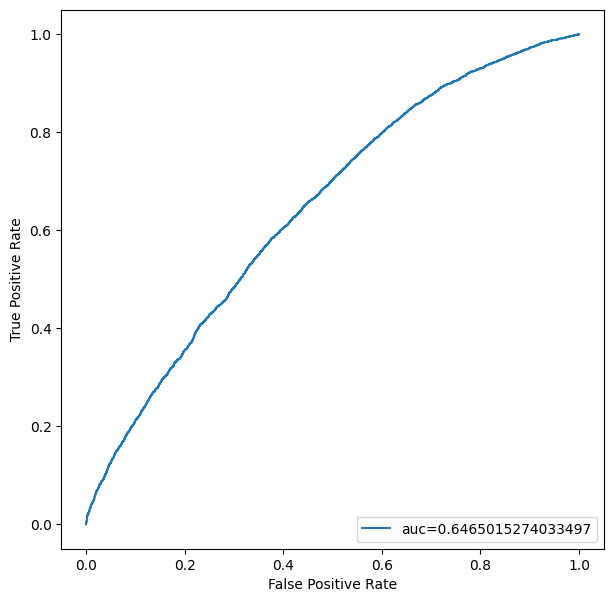

In [69]:
hyper_params_rf_randomized = {"max_features" : sp_randInt(8,15),
                              "max_depth" : sp_randInt(6,20),
                              "n_estimators" : sp_randInt(15,60),
                              'class_weight':["balanced","balanced_subsample"]
}

rf_clf = RandomForestClassifier(max_depth = 4, n_estimators=5)
random_cv_opt = RandomizedSearchCV(estimator=rf_clf, param_distributions=hyper_params_rf_randomized, n_iter=n_iter_randomsearch, cv = cv, n_jobs = n_jobs, random_state=random_state, scoring='roc_auc', verbose=1)
random_cv_opt.fit(X_train, y_train)
y_prd = random_cv_opt.predict(X_validation)
prf_score = precision_recall_fscore_support(y_validation, y_prd, average='binary')
y_prd_proba = random_cv_opt.predict_proba(X_validation)[:,-1]
score = roc_auc_score(y_validation, y_prd_proba)
print('best model hyper-parameter : ', random_cv_opt.best_params_)
print("precision, recall, f1score : ", prf_score)
print("roc_auc_score : ", score)

list_model_type.append("Model Optimization with Type 1 and Random Search")
list_model_roc_score.append(score)

plot_roc_auc(y_validation,y_prd_proba)

In [70]:
skf = StratifiedKFold(n_splits=4)
skf.get_n_splits(X_fs_sm_sampling, y_sm_sampling)

list_fold_result = []
for i, (train_index, test_index) in enumerate(skf.split(X_fs_sm_sampling, y_sm_sampling)):
  X_train_cv, X_test_cv = X_fs_sm_sampling.iloc[train_index, :], X_fs_sm_sampling.iloc[test_index, :]
  y_train_cv, y_test_cv = y_sm_sampling[train_index], y_sm_sampling[test_index]
  rf_clf = RandomForestClassifier()
  rf_clf.fit(X_train, y_train)
  y_prd = rf_clf.predict(X_validation)
  y_prd_proba = rf_clf.predict_proba(X_validation)[:,-1]
  prf_score = precision_recall_fscore_support(y_validation, y_prd, average='binary')
  score = roc_auc_score(y_validation, y_prd_proba)
  list_fold_result.append(score)
  print(i, " precision, recall, f1score : ", prf_score)
  print(i, " roc_auc_score : ", score)
average_auc = np.mean(list_fold_result)
print("average roc auc score : ",average_auc)
list_model_type.append("Model Optimization with Type 2")
list_model_roc_score.append(average_auc)

0  precision, recall, f1score :  (0.5399610136452242, 0.0753126699293094, 0.1321880219518015, None)
0  roc_auc_score :  0.6437512166669181
1  precision, recall, f1score :  (0.5116279069767442, 0.07177814029363784, 0.12589413447782546, None)
1  roc_auc_score :  0.6455936963424447
2  precision, recall, f1score :  (0.4943609022556391, 0.07150625339858618, 0.12494061757719715, None)
2  roc_auc_score :  0.6468325416168925
3  precision, recall, f1score :  (0.5318275154004107, 0.07041870581837956, 0.12436974789915967, None)
3  roc_auc_score :  0.6456202295582599
average roc auc score :  0.6454494210461288


Fitting 3 folds for each of 40 candidates, totalling 120 fits
best model hyper-parameter :  {'class_weight': 'balanced', 'max_depth': 18, 'max_features': 14, 'n_estimators': 59}
precision, recall, f1score :  (0.4249596557288865, 0.21479064709081022, 0.2853530792848113, None)
roc_auc_score :  0.6324773086381974


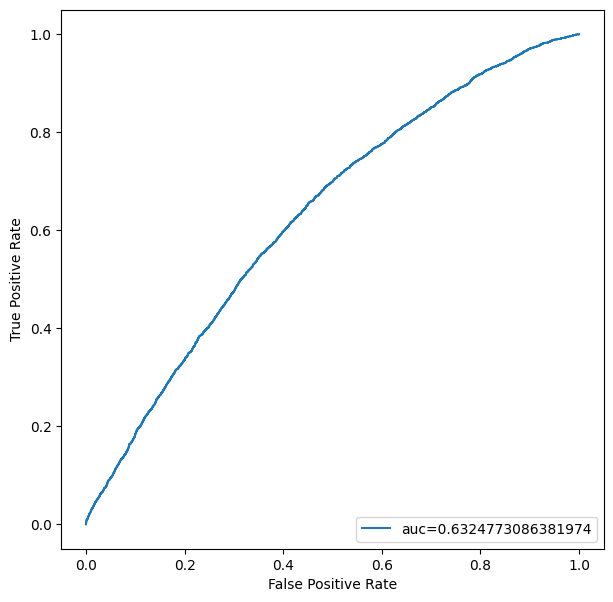

In [71]:
hyper_params_rf_randomized = {"max_features" : sp_randInt(8,15),
                              "max_depth" : sp_randInt(6,20),
                              "n_estimators" : sp_randInt(15,60),
                              'class_weight':["balanced","balanced_subsample"]
}

rf_clf = RandomForestClassifier(max_depth = 4, n_estimators=5)
random_cv_opt = RandomizedSearchCV(estimator=rf_clf, param_distributions=hyper_params_rf_randomized, n_iter=n_iter_randomsearch, cv = cv, n_jobs = n_jobs, random_state=random_state, scoring='roc_auc', verbose=1)
random_cv_opt.fit(X_fs_sm_sampling, y_sm_sampling)
y_prd = random_cv_opt.predict(X_validation)
prf_score = precision_recall_fscore_support(y_validation, y_prd, average='binary')
y_prd_proba = random_cv_opt.predict_proba(X_validation)[:,-1]
score = roc_auc_score(y_validation, y_prd_proba)
print('best model hyper-parameter : ', random_cv_opt.best_params_)
print("precision, recall, f1score : ", prf_score)
print("roc_auc_score : ", score)

list_model_type.append("Model Optimization with Type 2 and Random Search")
list_model_roc_score.append(score)

plot_roc_auc(y_validation,y_prd_proba)

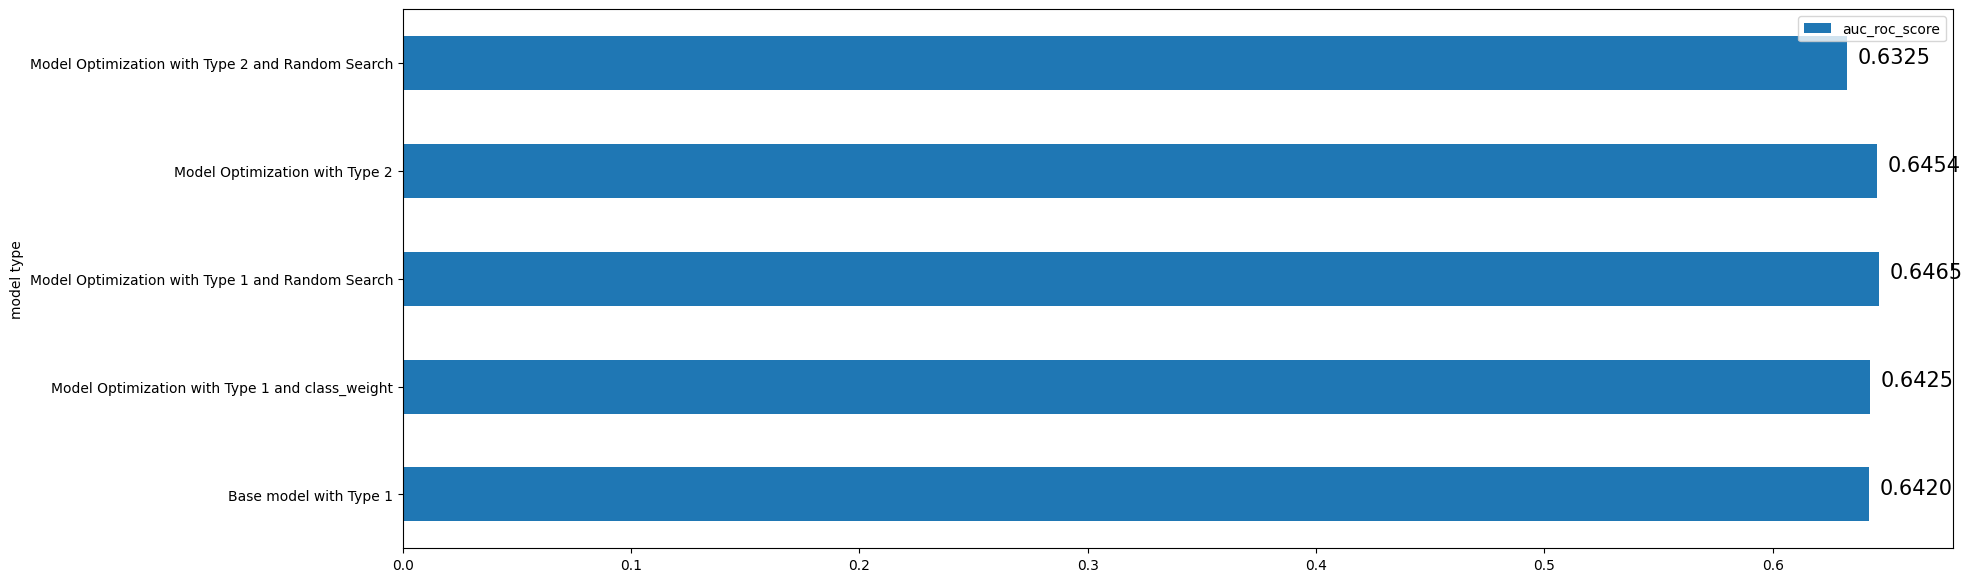

In [72]:
df_compare = pd.DataFrame({'model type':list_model_type, 'auc_roc_score':list_model_roc_score})
ax = df_compare.plot.barh(x='model type', y='auc_roc_score', rot=0, figsize=(20,7))
for bar in ax.patches:
    ax.annotate(format(bar.get_width(), '.4f'),
                   (bar.get_width(), bar.get_y() + bar.get_height() / 2), 
                   size=15, xytext=(8, 0),
                   textcoords='offset points')

In [73]:
# reproduction
rf_clf = RandomForestClassifier(**{'class_weight': 'balanced', 'max_depth': 9, 'max_features': 12, 'n_estimators': 57})
final_model = rf_clf.fit(X_train, y_train)

<BarContainer object of 77 artists>

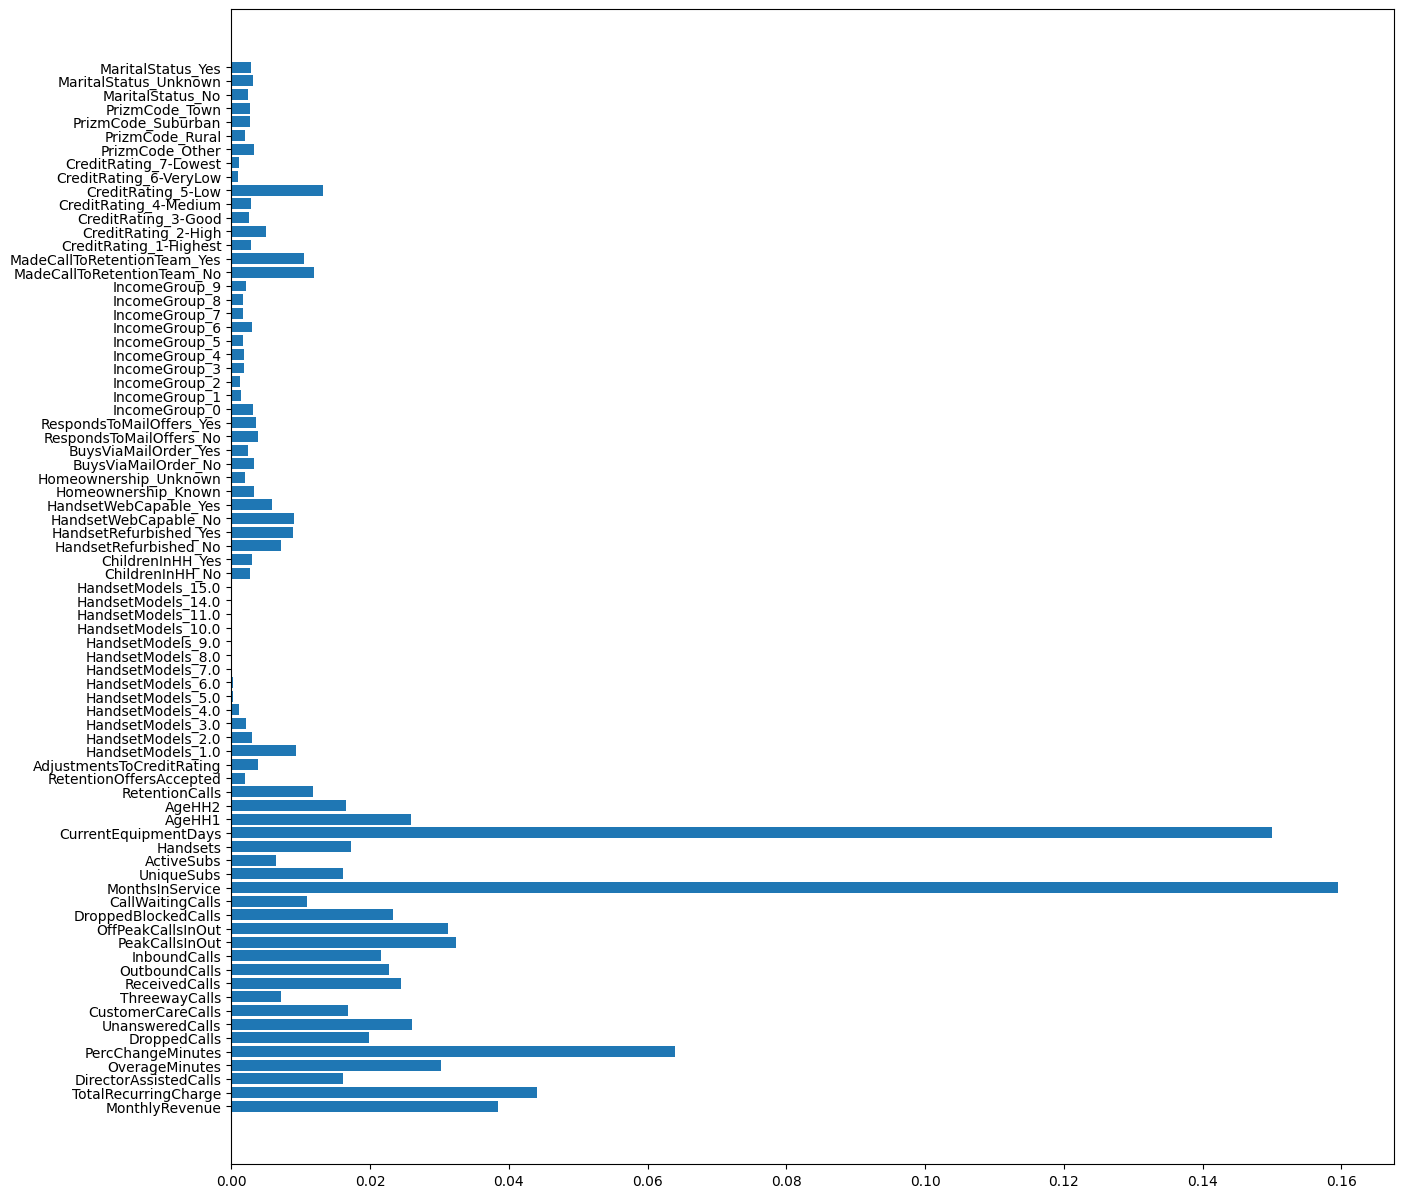

In [74]:
plt.figure(figsize=(15,15))
plt.barh(list(X_fs_sm_sampling.columns),rf_clf.feature_importances_)

In [75]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_validation)

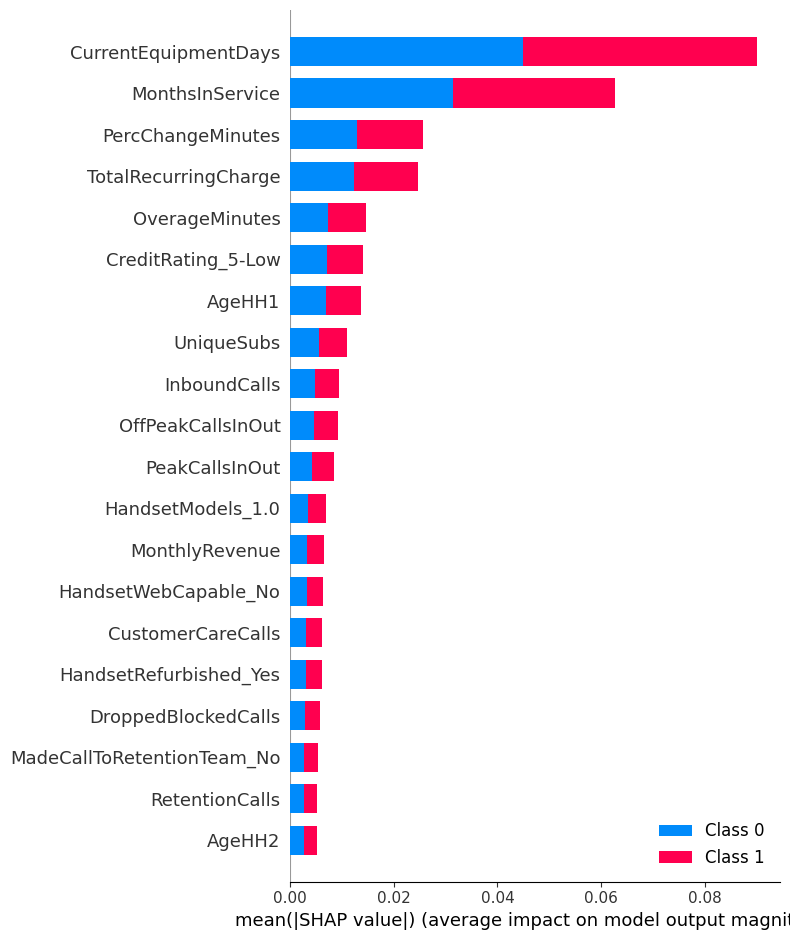

In [76]:
shap.summary_plot(shap_values, X_validation)